In [1]:
%load_ext autoreload
%autoreload 2

from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
from aux import format_plot
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from time import time

plt.rcParams['font.family'] = 'Helvetica'

dt = 0.0001

In [2]:
def gen_gaussian(x, u, s):
    return 1 / np.sqrt(2 * np.pi * s**2) * np.exp(-0.5 * (x - u)**2 / s**2)

def gen_wrapped_gaussian(x, u, s):
    d = np.minimum(np.abs(x - u), np.abs(x + x[-1] - u))
    return 1 / np.sqrt(2 * np.pi * s**2) * np.exp(-0.5 * d**2 / s**2)

In [62]:
class LinearSystem:
    def __init__(
        self,
        n,
        u_func,
        reset_func,
        tau=1.0,
        x_init=None,
        noise_std=0,
        weight_perturbation=0,
        learning_rate=1,
        homeo_rate=0.05,
        alpha=1,
        w_inh=None,
        w_e_scale=1,
        w_pool_to_shift=0.5,
        w_shift_to_pool=0.5,
        presyn_setpoint=8,
    ):
        """
        Initialize n-dim linear system
        """
        if callable(u_func):
            self.u_func = u_func
            self.u_constant = None
        else:
            u_array = np.array(u_func)
            self.u_func = lambda t: u_array
            self.u_constant = u_array

        self.reset_func = reset_func
        self.tau = tau
        self.learning_rate = learning_rate
        self.homeo_rate = homeo_rate
        self.alpha = alpha
        self.n = n
        self.presyn_setpoint = presyn_setpoint

        # ---- NEW: z filter time constant
        self.tau_z = 0.02
        self.tau_m = 1e-2

        # Initialize weights
        self.W0 = np.zeros((3 * n, 3 * n))
        shift_mats_pool_pool = []
        for i in range(1, n):
            w_shift = (
                np.diag(np.ones(n - np.abs(i)), k=i)
                * 0.5
                * (1 + np.cos(2 * np.pi * np.abs(i) / n))
            )
            shift_mats_pool_pool.append(w_shift)
            shift_mats_pool_pool.append(np.transpose(w_shift))
        weight_pert = np.random.normal(size=(n, n), scale=weight_perturbation, loc=1)
        self.W0[:n, :n] = w_e_scale * np.sum(np.stack(shift_mats_pool_pool), axis=0) * weight_pert

        self.W0[:n, n:2 * n] = w_shift_to_pool * (
            np.diag(np.ones((n - 1,)), k=1)
            # + 0.5 * np.diag(np.ones((n - 2,)), k=2)
        )
        self.W0[:n, 2 * n:3 * n] = w_shift_to_pool * (
            np.diag(np.ones((n - 1,)), k=-1)
            # + 0.5 * np.diag(np.ones((n - 2,)), k=-2)
        )

        w_side_pool = (np.diag(np.ones(n,)) + 0.5 * (np.diag(np.ones(n-1,), k=1) + np.diag(np.ones(n-1,), k=-1)) - 1) * w_pool_to_shift
        self.W0[n:2 * n, :n] = w_side_pool
        self.W0[2 * n:3 * n, :n] = w_side_pool

        if w_inh is None:
            self.w_inh = np.concatenate([np.ones((n,)), np.zeros((2 * n,))])
        else:
            self.w_inh = w_inh

        self.x0 = np.zeros(3 * n) if x_init is None else np.array(x_init)

    def system_dynamics(self, t, state_flat):
        """
        System of differential equations: d/dt [x, z_filt, W]
        """
        n = self.n
        W_dim = 3 * n

        # ---- Unpack state
        x_in = state_flat[:W_dim]
        z_filt = state_flat[W_dim:W_dim + n]
        W = state_flat[W_dim + n:].reshape((W_dim, W_dim))

        # Ensure non-negative activity
        x = np.clip(x_in, 0, None)

        w_inh = self.w_inh
        u_t = np.array(self.u_func(t))

        # ---- State dynamics
        dx_dt_raw = (1 / self.tau_m) * ((W - w_inh) @ x - x + u_t)
        dx_dt = np.where(
            np.logical_and(x <= 0, dx_dt_raw < 0),
            0,
            dx_dt_raw,
        )

        # ---- Weight dynamics
        x_ct_1 = x[:n]
        x_ct_2 = x[n:3 * n]

        z = W[:n, n:3 * n] @ x_ct_2

        # ---- NEW: z low-pass filter
        dz_filt_dt = (z - z_filt) / self.tau_z

        # ---- NEW: rectified high-pass signal
        z_hp = np.maximum(z - z_filt, 0.0)

        comp_to_bound = self.presyn_setpoint - W[:n, :n].sum(axis=0)

        dw_dt_ct_1 = (
            self.learning_rate
            * z_hp
            * np.outer(self.alpha * z - dx_dt[:n], x_ct_1)
        ) + self.homeo_rate * np.where(comp_to_bound > 0, 0, comp_to_bound)[None, :] # * W[:n, :n]
        # if t > 0.1 and t < 0.2 and np.any(z_hp > 0) and np.any(z > 0): 
        #     print('start', t)
        #     print(z_hp)
        #     print(z)
        #     print(dx_dt[:n])

        np.fill_diagonal(dw_dt_ct_1, 0)

        dw_dt = np.zeros((W_dim, W_dim))
        dw_dt[:n, :n] = dw_dt_ct_1

        # ---- Flatten derivatives
        dstate_flat = np.concatenate([
            dx_dt,
            dz_filt_dt,
            dw_dt.ravel(),
        ])

        return dstate_flat

    def simulate(self, t_span, dt=0.002):
        """
        Simulate system over [t_span[0], t_span[1]] with step dt.
        """
        n = self.n
        W_dim = 3 * n

        t_eval = np.arange(t_span[0], t_span[1], dt)

        # ---- Initial conditions
        z_filt0 = np.zeros(n)
        initial_state = np.concatenate([
            self.x0,
            z_filt0,
            self.W0.ravel(),
        ])

        sol = solve_ivp(
            fun=self.system_dynamics,
            t_span=t_span,
            y0=initial_state,
            t_eval=t_eval,
            method="RK23",
            rtol=1e-7,
            atol=1e-7,
        )

        if not sol.success:
            print("Integration failed:", sol.message)

        solution = sol.y.T

        x_out = solution[:, :W_dim]
        z_filt_out = solution[:, W_dim:W_dim + n]
        W_out = solution[:, W_dim + n:].reshape(len(t_eval), W_dim, W_dim)

        u_history = np.array([self.u_func(time) for time in t_eval])

        return t_eval, x_out, W_out, u_history

# Modified simulation function
def run_simulation(
    n=5,
    u_funcs=None,
    reset_funcs=None,
    x_init_peak_locs=None,
    peak_amp=5,
    learning_rate=1,
    homeo_rate=0.05,
    alpha=1,
    seed=None,
    t_sim=(0, 200),
    weight_perturbation=0,
    color_by=None,
    reinitialize=False,
    noise_std=0,
    tau=2,
    save_path=None,
    make_cbar=False,
    w_inh=None,
    w_e_scale=1,
    w_max=None,
    w_pool_to_shift=0.5,
    w_shift_to_pool=0.5,
    presyn_setpoint=8,
    cbar_label=None,
    y_lim_1=None,
    y_lim_2=None,
    y_lim_3=None,
    y_lim_4=None,
    firing_rate_max=None,
    width=1,
    plot_individual_traces=True,
    w_diff_scale=0.1,
):
    """
    Run simulation with time-varying input
    
    Parameters:
    u_func: function that takes time t and returns [u1(t), u2(t)]
           if None, uses constant input [0.5, 0.5]
    """
    
    # Multiple initial conditions for x1_init
    if seed:
        np.random.seed(seed)

    if x_init_peak_locs is None:
        n_trials = len(u_funcs) if u_funcs is not None else 20
        x_init_peak_locs = np.clip(np.linspace(0.15, 0.85, n_trials), 0, 1)
                                           
    s = 1.5
                                           
    x = np.arange(n)
    
    x_init_values = [
        np.concatenate([
            np.clip(
                peak_amp * gen_gaussian(x, x_init_peak_loc * (n-1), s),
                0,
                None,
            ),
            np.zeros((2*n)),
        ])
        for x_init_peak_loc in x_init_peak_locs
    ]
    
    w_inh_full = np.zeros((3*n, 3*n))
    w_inh_full[:n, :n] =  w_inh[:, None]

    # Default to constant input for backward compatibility
    if u_funcs is None:
        u_funcs = [lambda t: np.concatenate([np.ones((n)) * 0.5, np.zeros((2*n))])] * len(x_init_values)
    if reset_funcs is None:
        reset_funcs = [lambda t: 0] * len(x_init_values)

    cmap = sns.color_palette('magma', as_cmap=True)
    if color_by is None:
        color_var = x_init_peak_locs
    else:
        m = np.abs(color_by).max()
        color_var = 0.5 * (1 + color_by/m)
    colors = cmap(color_var)
    
    # Storage for all simulations
    all_results = []
    
    print(f"Running simulations for {len(x_init_values)} initial conditions...")
    
    scale = 0.6
    fig_all, axes_all = plt.subplots(1, 1, figsize=(4 * scale * width, 4 * scale))
    axes_all.set_xlabel('Time (s)')
    axes_all.set_ylabel('Bump loc.')
    axes_all.set_ylim(0, 10)
    
    fig_corr, axes_corr = plt.subplots(1, 1, figsize=(4 * scale * width, 4 * scale))
    axes_corr.set_xlabel('Integrated input (AU)')
    axes_corr.set_ylabel('Bump loc.')
    # axes_corr.set_ylim(0, 10)
    axes_corr.set_xlim(-0.1, 1.1)
    
    for i, (x_init, color) in enumerate(zip(x_init_values, colors)):
        # Create system with this initial condition and time-varying input
                                
        system = LinearSystem(
            n,
            u_funcs[i],
            reset_funcs[i],
            tau,
            x_init=x_init,
            noise_std=0, 
            weight_perturbation=weight_perturbation,
            learning_rate=learning_rate,
            homeo_rate=homeo_rate,
            alpha=alpha, w_inh=w_inh_full,
            w_e_scale=w_e_scale,
            w_pool_to_shift=w_pool_to_shift,
            w_shift_to_pool=w_shift_to_pool,
            presyn_setpoint=presyn_setpoint,
        )
        
        # Simulate
        begin = time()
        t, x, w, u_history = system.simulate(t_sim, dt=dt)
        all_results.append((t, x, w, u_history))
        
        print(f'Finished sim {i+1}: {time() - begin}')
        
        # State variables (position 1 - original (0,0) plot)
        loc_trace = np.dot(np.arange(n), (x[:, :n] / (x[:, :n].sum(axis=1)[:, None] + 1e-6)).T)

        loc_trace = np.where(x[:, :n].sum(axis=1) > 1e-3, loc_trace, np.nan)
        
        
        if plot_individual_traces:
            # Set up the plot - now 4 rows, 1 column
            scale = 0.4
            fig, axes = plt.subplots(3, 1, figsize=(12 * scale * width, 14 * scale))
            scale = 0.8
            fig_w, axes_w = plt.subplots(3, 1, figsize=(4 * scale * width, 7 * 1.5 * scale))
            fig_w_dyn, axes_w_dyn = plt.subplots(1, 1, figsize=(4 * scale * width, 3.5 * scale))
            
            m = np.abs(x.T[:n, :]).max() * 1.05 if firing_rate_max is None else firing_rate_max
            mappable = axes[0].matshow(
                x.T[:n, :],
                aspect='auto',
                vmin=0,
                vmax=m,
                cmap=sns.color_palette('afmhot', as_cmap=True),
            )
            cbar_0 = plt.colorbar(mappable, ax=axes[0])
            axes[0].set_xticks([0, int(t_sim[1]/dt)], [0, t_sim[1]])
            axes[0].set_yticks([0, n-1], [1, n])
            
            m = np.abs(x.T[n:, :]).max() * 1.05
            if m == 0:
                m = 1
            mappable = axes[1].matshow(
                x.T[n:, :],
                aspect='auto',
                vmin=0,
                vmax=m,
                cmap=sns.color_palette('afmhot', as_cmap=True),
            )
            cbar_1 = plt.colorbar(mappable, ax=axes[1])
            axes[1].set_xticks([0, int(t_sim[1]/dt)], [0, t_sim[1]])
            axes[1].set_yticks([0, 2*n-1], [1, 2*n])


            axes[2].plot(
                t,
                loc_trace,
                color=color,
                linewidth=1.5,
                alpha=0.8,
            )

            axes[0].set_yticks([0, n-1], [1, n])
            
            if w_max is None:
                w_max = np.abs(w).max() * 1.05

            axes_w[0].matshow(w[0, :, :], cmap='bwr', vmin=-w_max, vmax=w_max)
            axes_w[1].matshow(w[-1, :, :], cmap='bwr', vmin=-w_max, vmax=w_max)
            axes_w[2].matshow(w[-1, :, :] - w[0, :, :], cmap='bwr', vmin=-w_diff_scale, vmax=w_diff_scale)

            for i_w in range(n):
                for j_w in range(n):
                    axes_w_dyn.plot(np.arange(w.shape[0]) * dt, w[:, i_w, j_w])

            axes[0].set_xlabel('Time (s)')
            axes[0].set_ylabel('Cell')
            
            axes[1].set_xlabel('Time (s)')
            axes[1].set_ylabel('Cell')

            axes[2].set_xlabel('Time (s)')
            axes[2].set_ylabel('Bump loc.')

            for k in range(2):
                axes_w[k].set_xlabel('Presyn index')
                axes_w[k].set_ylabel('Postsyn index')

            format_plot(axes)
            fig.tight_layout()
            format_plot(axes_w)
            fig_w.tight_layout()
            format_plot(axes_w_dyn)
            fig_w_dyn.tight_layout()
            format_plot(cbar_0.ax)
            format_plot(cbar_1.ax)
        
        axes_corr.scatter(color_var[i], loc_trace[-1], color='black', s=2)
        
        axes_all.plot(
            t,
            loc_trace,
            color=color,
            linewidth=1.5,
            alpha=0.8,
        )
    
    format_plot(axes_all)
    fig_all.tight_layout()
    
    format_plot(axes_corr)
    fig_corr.tight_layout()
    
#     fig_all.savefig(save_path + '_all_paths' + '.svg')
#     fig_corr.savefig(save_path + '_corr' + '.svg')
    
    
#     if save_path is not None:
#         fig.savefig(save_path + '.png', bbox_inches='tight')
#         fig.savefig(save_path + '.svg', bbox_inches='tight')
    
    return all_results


### Assess ability of continuous attractor network to hold the value of a particular stimulus

First, wire up a well-tuned continuous attractor & check it can persist the value of a particular stimulus it receives. 

Then, perturb inhibitory synapses by a normally distributed factor. We expect this to destroy the symmetry of the weight matrix, causing the attractor to bifurcate to one or more fixed points, and causing stimuli to not be persisted and rather leak toward one of the fixed points.

Running simulations for 20 initial conditions...
Finished sim 1: 0.1909806728363037
Finished sim 2: 0.13100910186767578
Finished sim 3: 0.12162113189697266
Finished sim 4: 0.12828707695007324
Finished sim 5: 0.12546706199645996
Finished sim 6: 0.1262068748474121
Finished sim 7: 0.135300874710083


/var/folders/rp/n8h2l6w51774kxnq18z19s8r0000gn/T/ipykernel_1155/2951039584.py:315: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(3, 1, figsize=(12 * scale * width, 14 * scale))


Finished sim 8: 0.12465381622314453
Finished sim 9: 0.13714313507080078
Finished sim 10: 0.13851594924926758
Finished sim 11: 0.14129090309143066
Finished sim 12: 0.13112401962280273
Finished sim 13: 0.13176894187927246
Finished sim 14: 0.13045692443847656
Finished sim 15: 0.13924193382263184
Finished sim 16: 0.1436176300048828
Finished sim 17: 0.12202596664428711
Finished sim 18: 0.13508200645446777
Finished sim 19: 0.1339099407196045
Finished sim 20: 0.13682913780212402


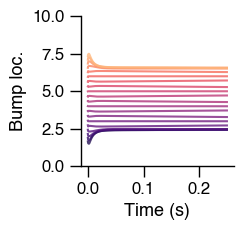

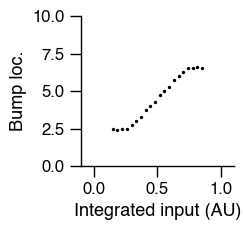

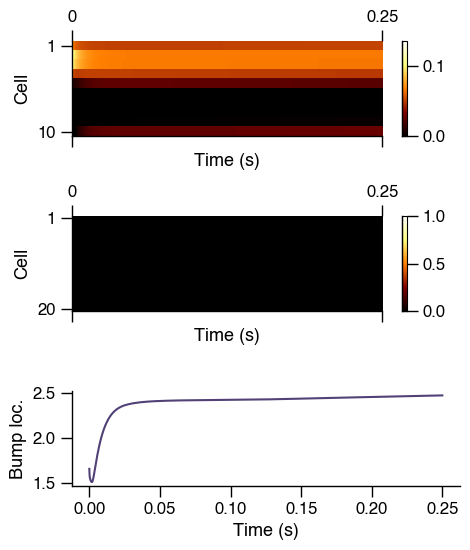

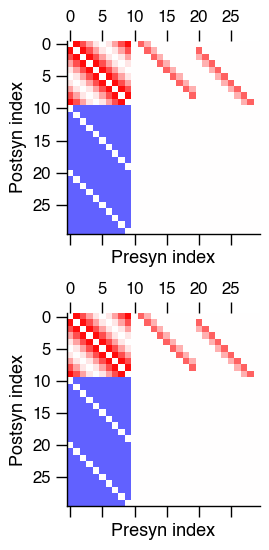

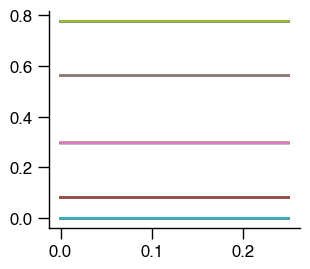

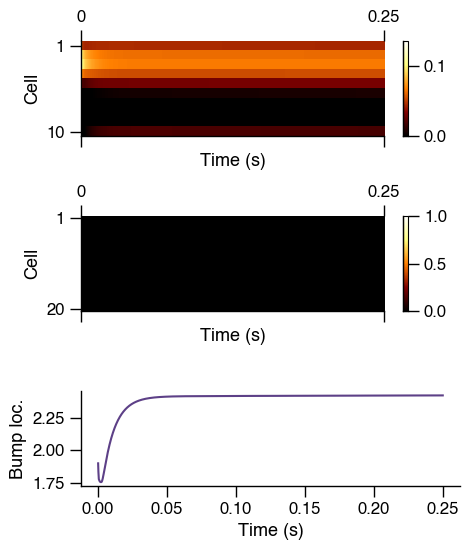

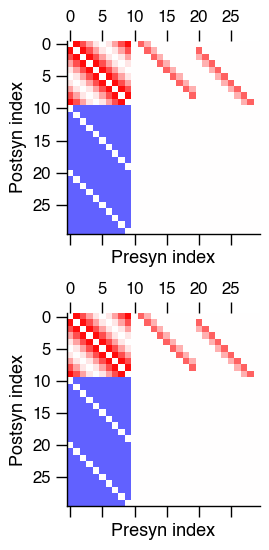

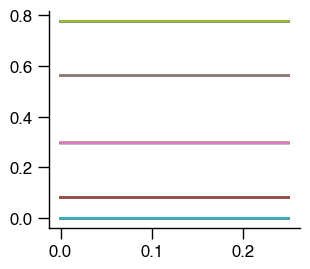

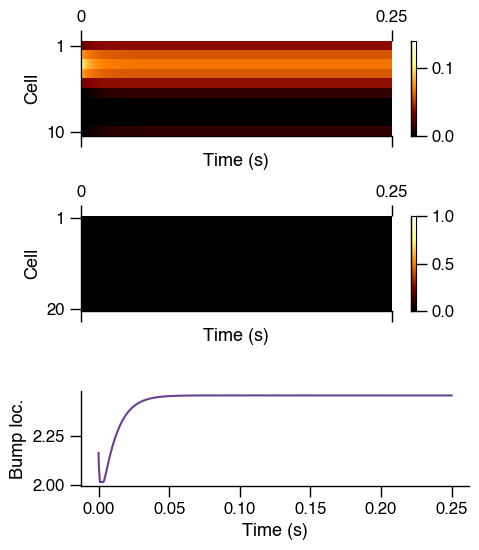

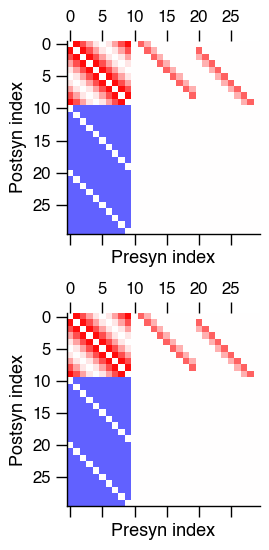

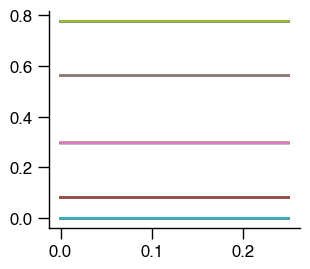

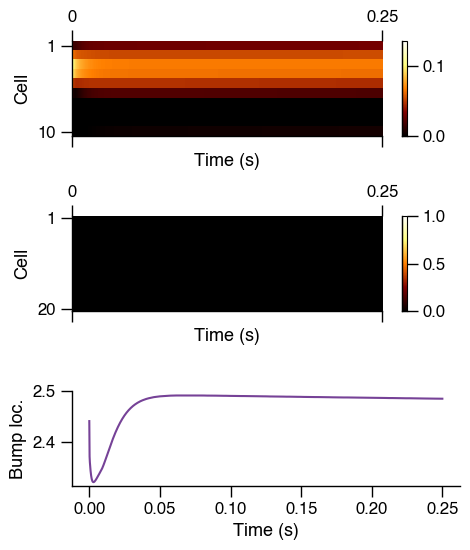

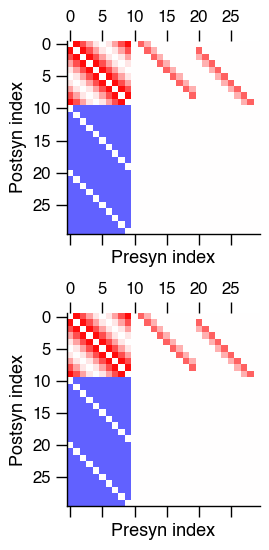

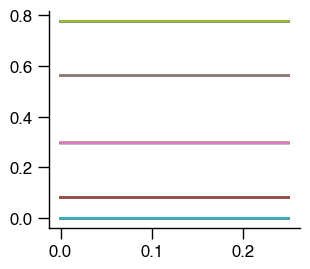

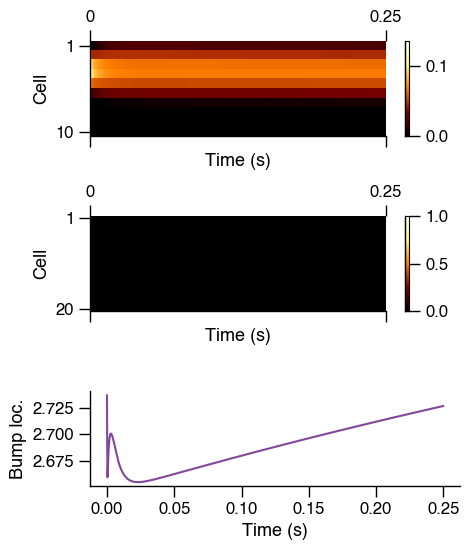

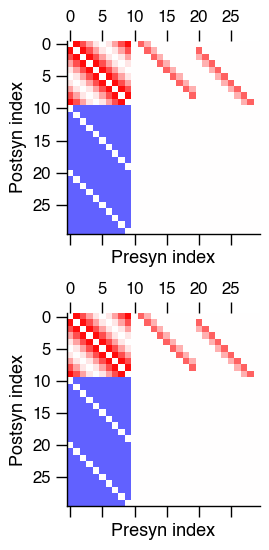

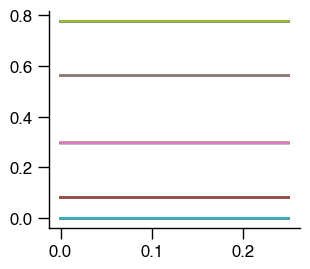

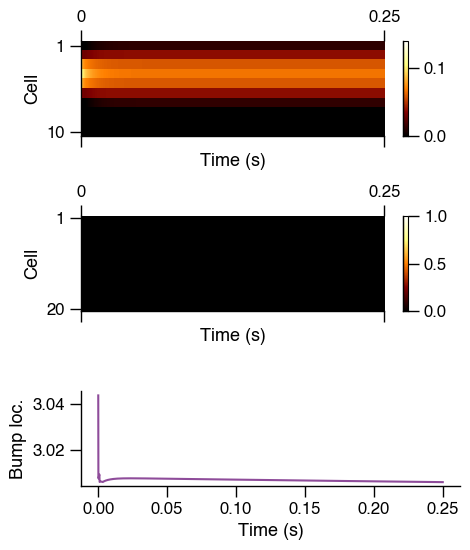

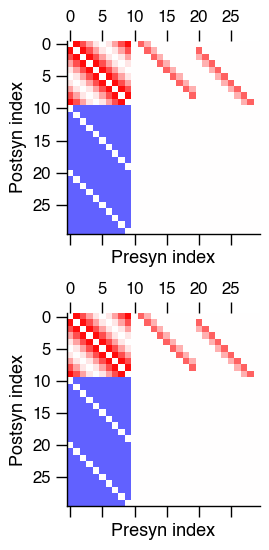

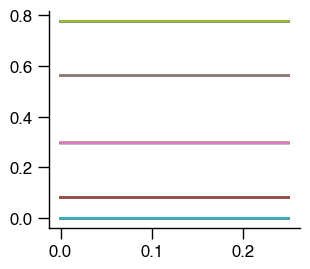

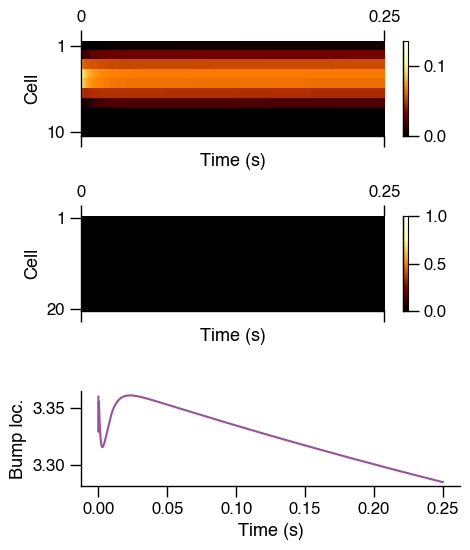

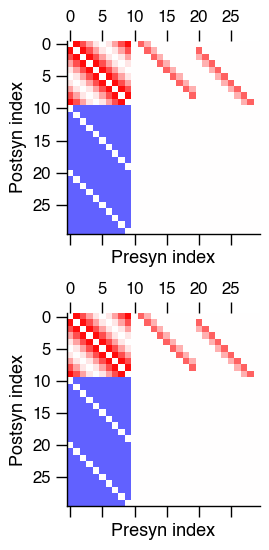

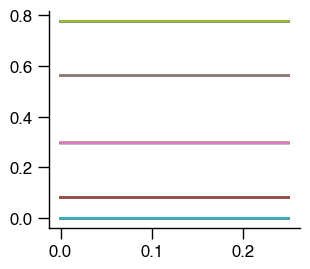

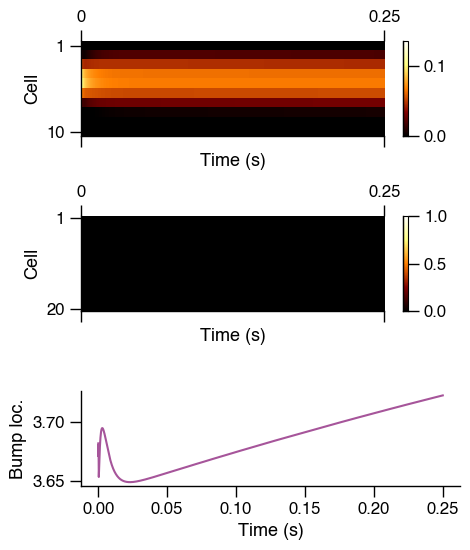

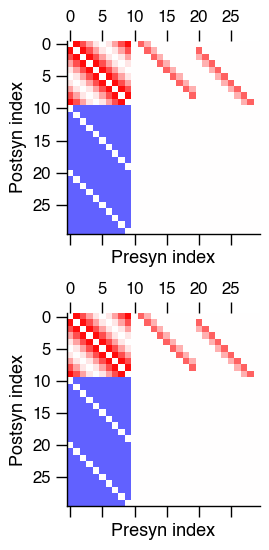

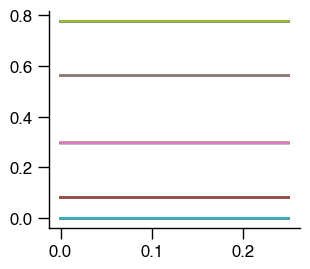

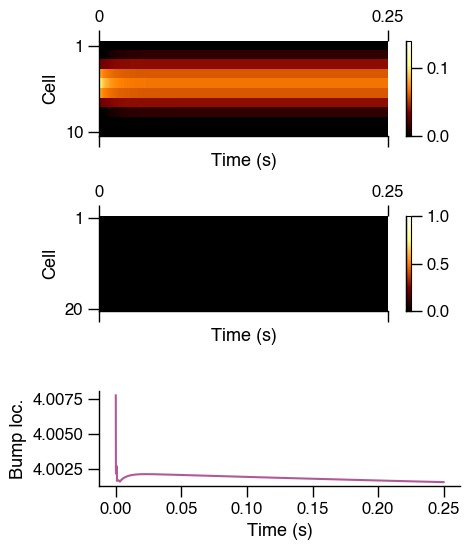

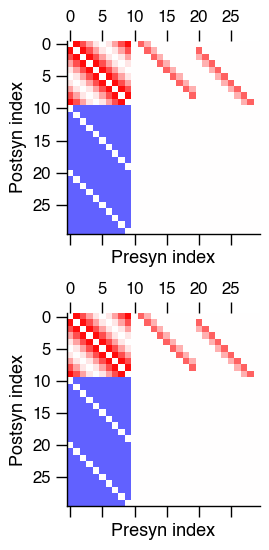

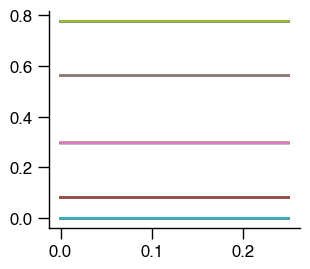

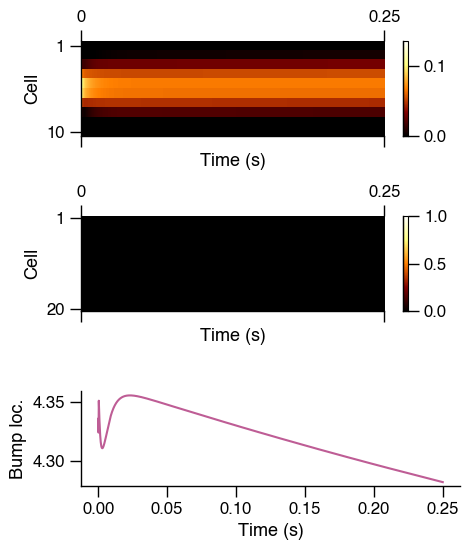

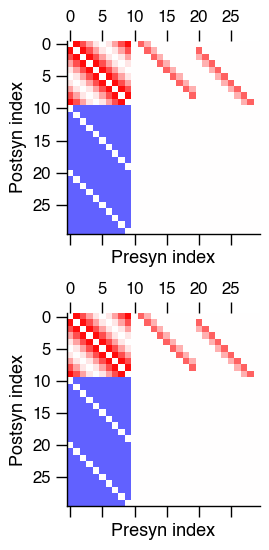

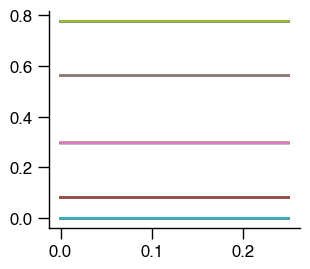

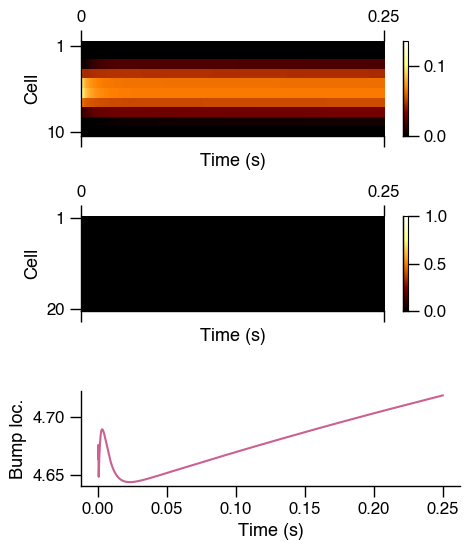

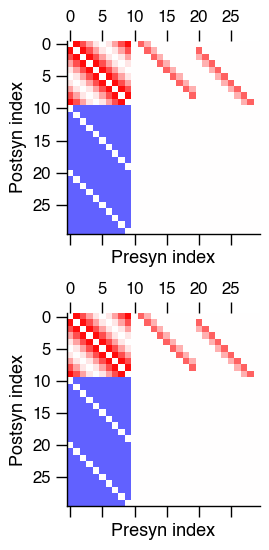

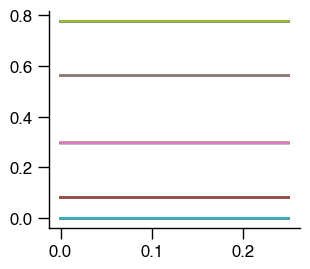

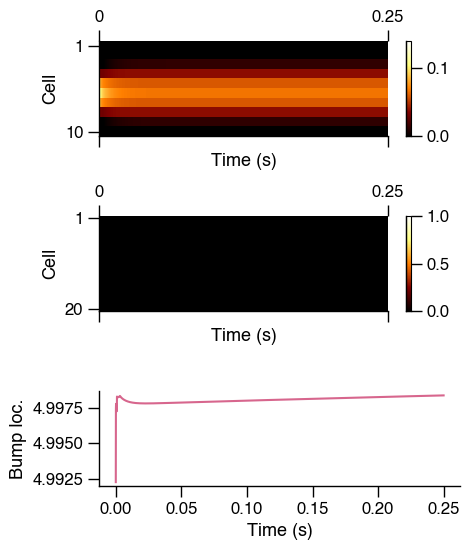

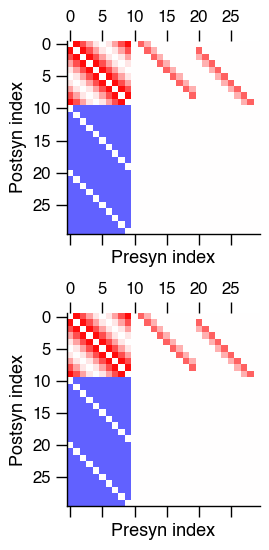

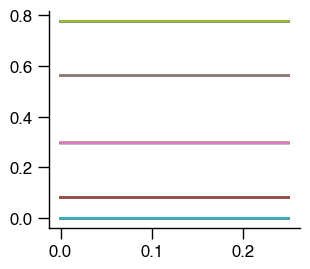

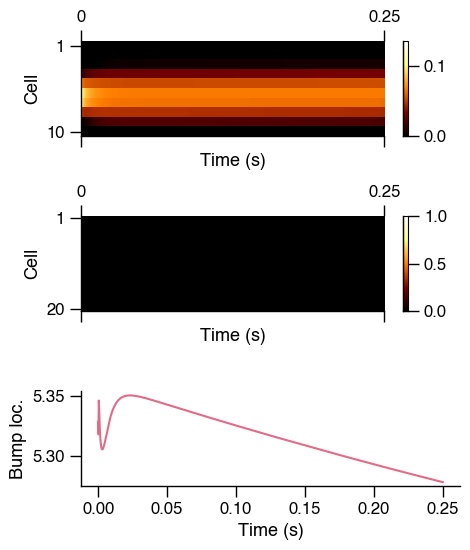

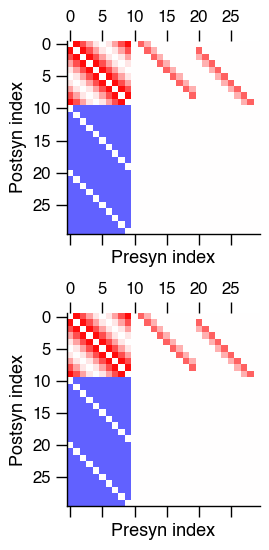

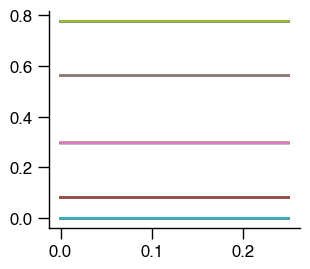

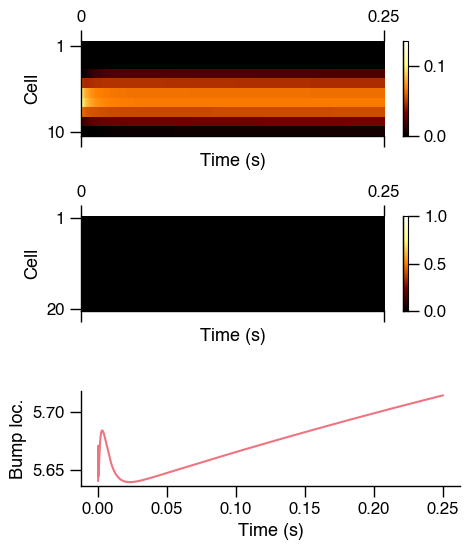

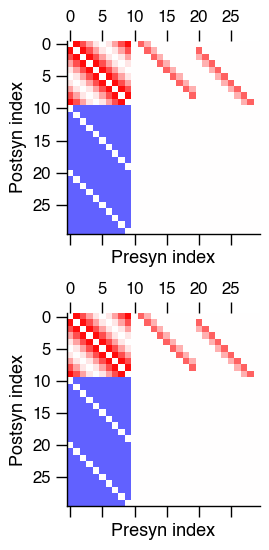

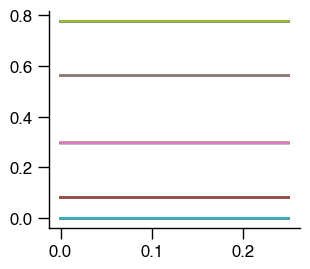

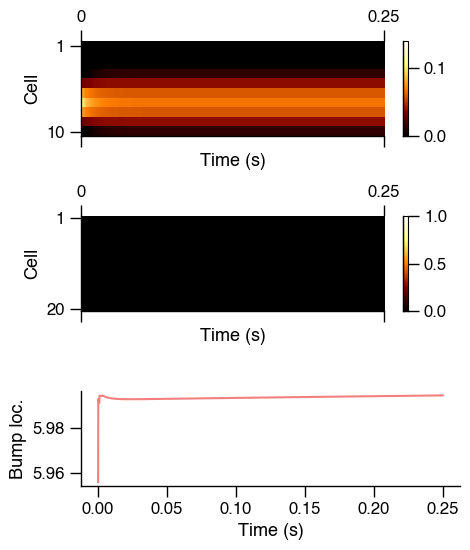

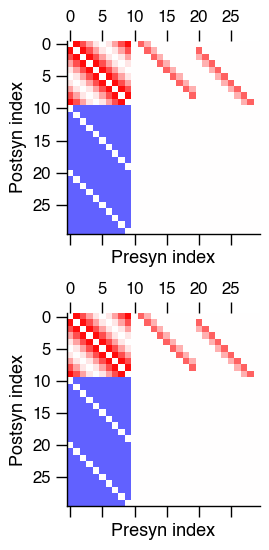

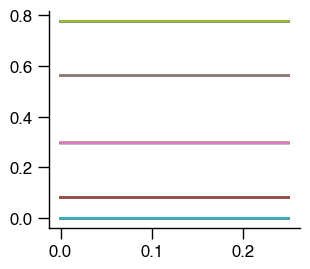

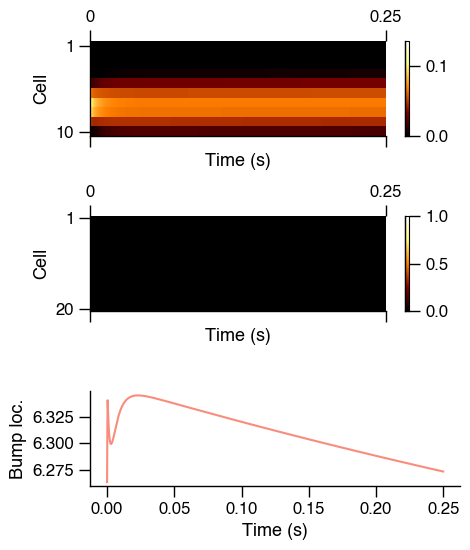

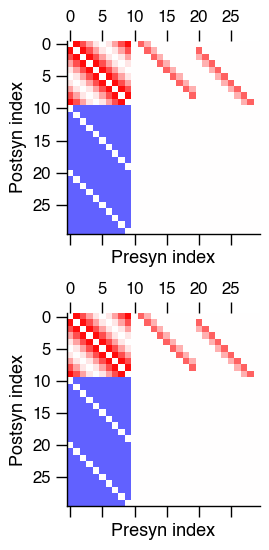

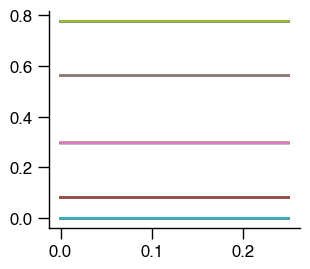

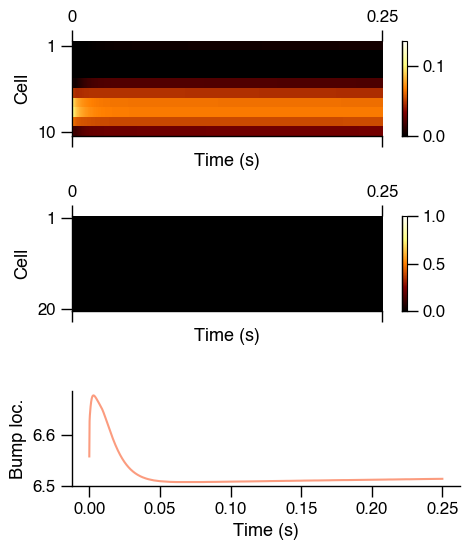

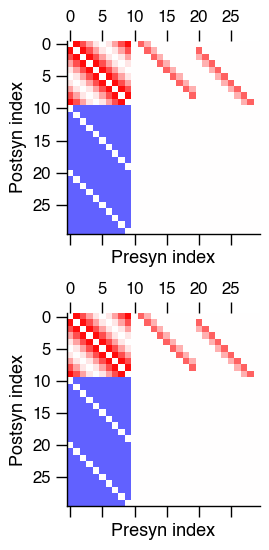

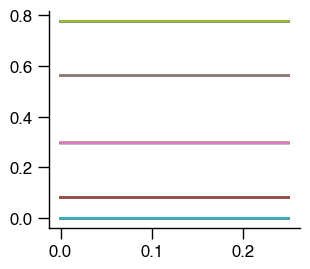

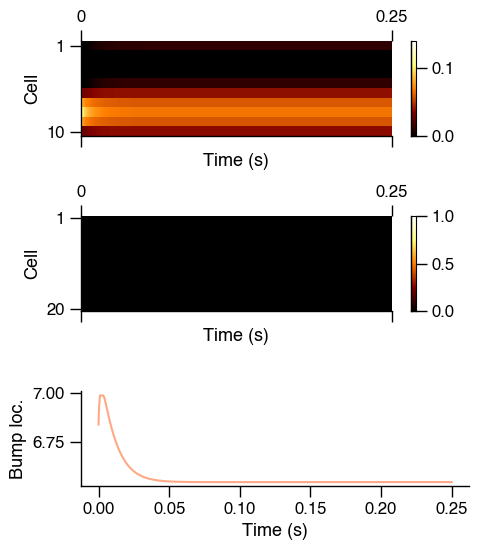

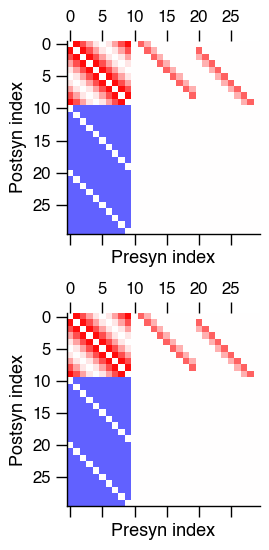

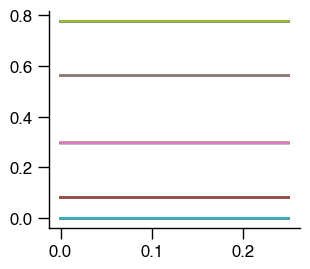

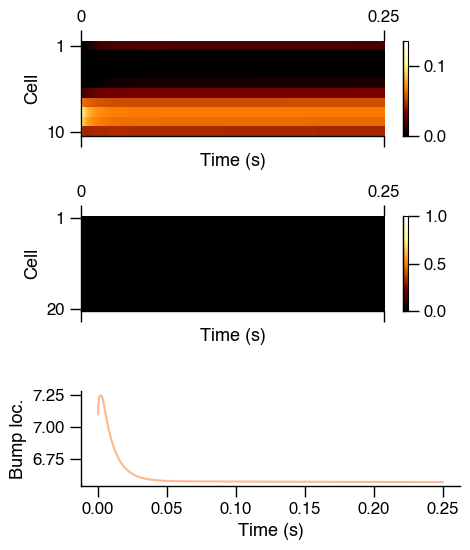

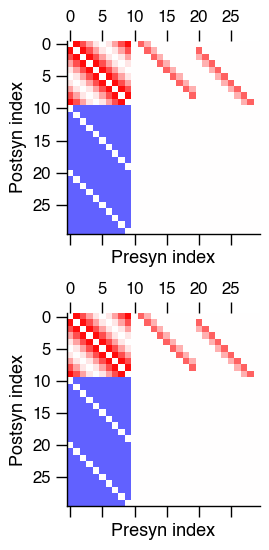

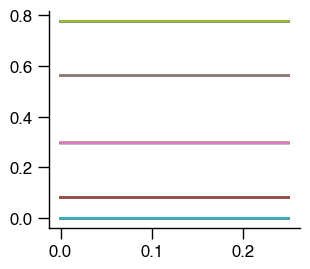

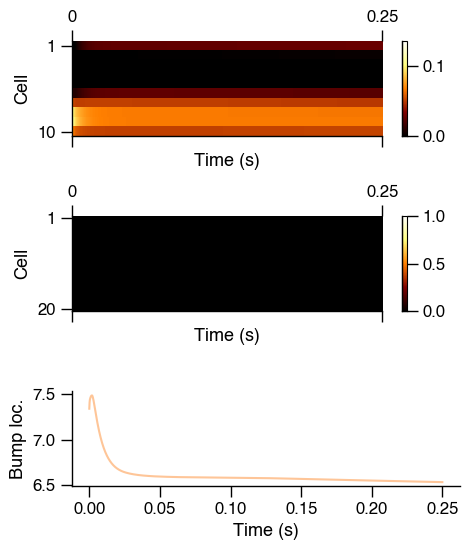

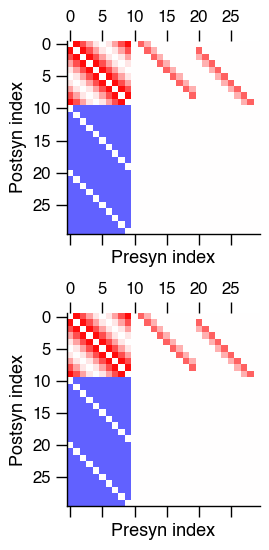

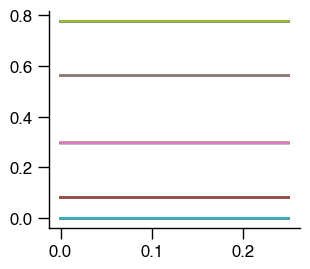

In [5]:
n = 10

run_simulation(
    peak_amp=0.5,
    n=n,
    homeo_rate=0,
    learning_rate=0,
    seed=15,
    weight_perturbation=0,
    noise_std=0.2,
    t_sim=(0, 0.25),
    make_cbar=True,
    w_e_scale=0.857,
    w_inh=np.random.normal(size=(n,), loc=1, scale=0) * 2,
#     firing_rate_max=0.3,
    plot_individual_traces=True,
)
None

Running simulations for 20 initial conditions...
Finished sim 1: 1.8820369243621826
Finished sim 2: 1.836820125579834
Finished sim 3: 2.2733170986175537
Finished sim 4: 1.572941780090332
Finished sim 5: 1.7459628582000732
Finished sim 6: 1.618682861328125
Finished sim 7: 1.6380910873413086


/var/folders/rp/n8h2l6w51774kxnq18z19s8r0000gn/T/ipykernel_1155/3720246593.py:315: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(3, 1, figsize=(12 * scale * width, 14 * scale))


Finished sim 8: 2.0075769424438477
Finished sim 9: 2.5828001499176025
Finished sim 10: 1.683600902557373
Finished sim 11: 2.0186619758605957
Finished sim 12: 2.5369420051574707
Finished sim 13: 1.8198504447937012
Finished sim 14: 1.5623700618743896
Finished sim 15: 1.7510662078857422
Finished sim 16: 1.6186299324035645
Finished sim 17: 1.692046880722046
Finished sim 18: 1.6779062747955322
Finished sim 19: 1.6760990619659424
Finished sim 20: 1.6220159530639648


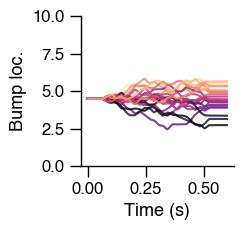

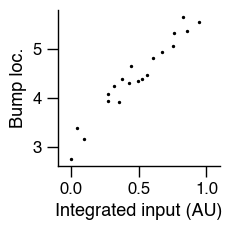

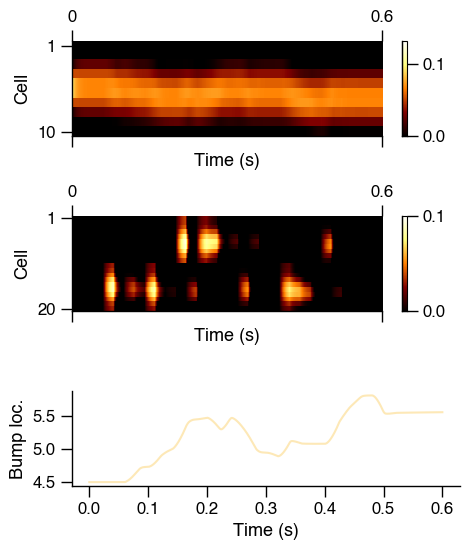

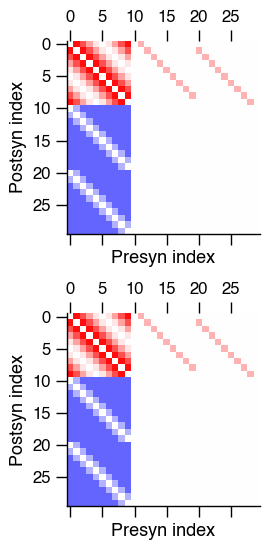

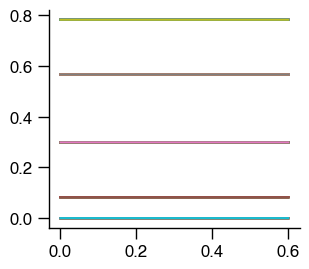

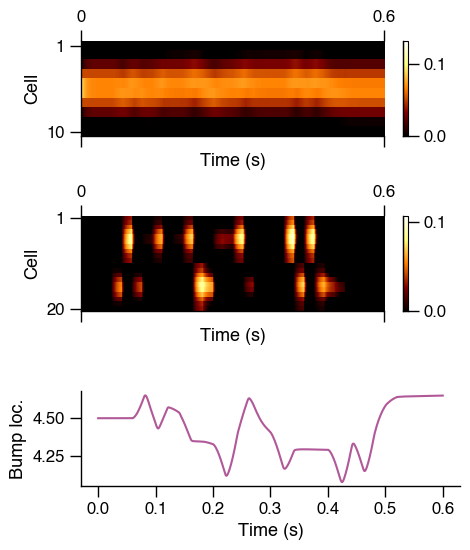

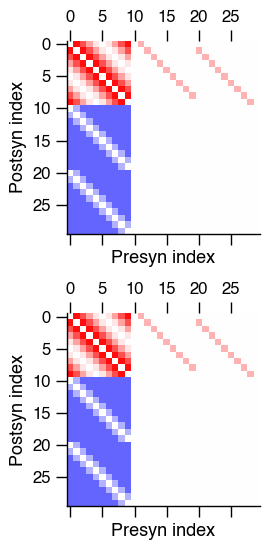

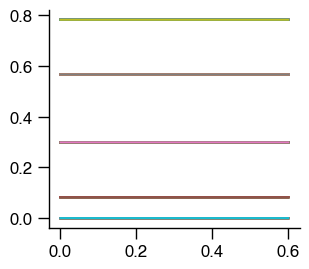

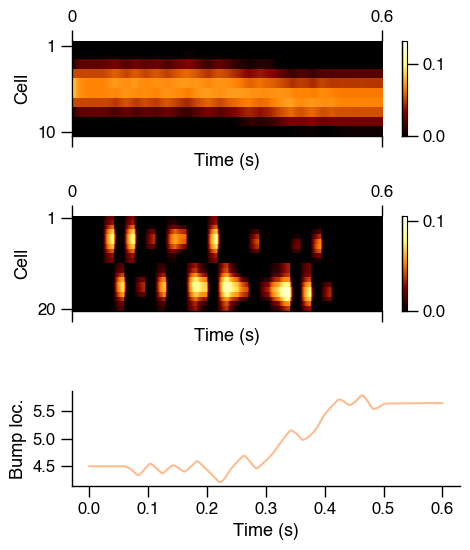

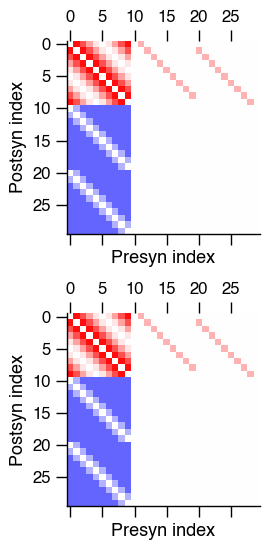

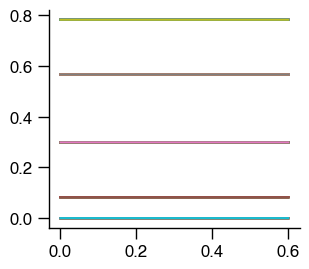

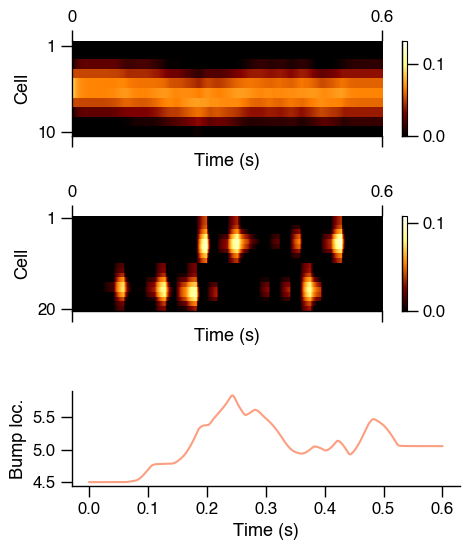

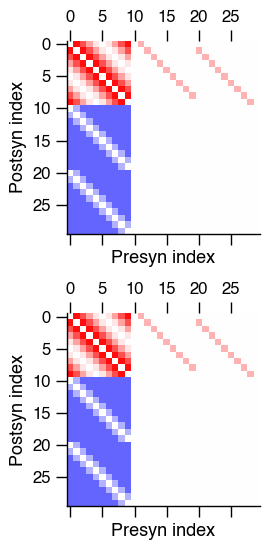

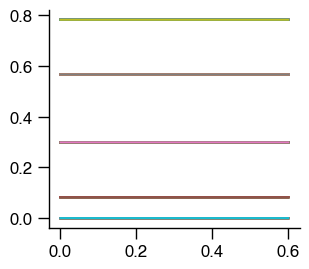

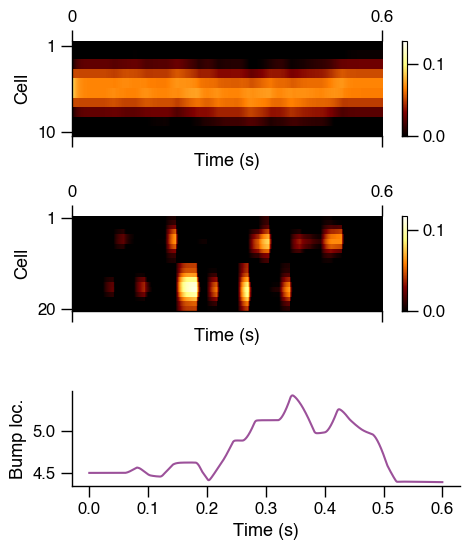

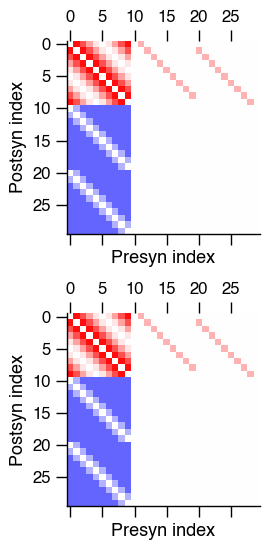

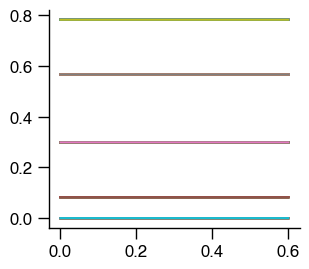

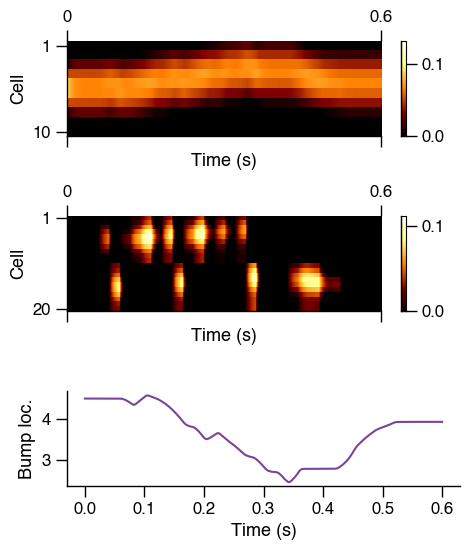

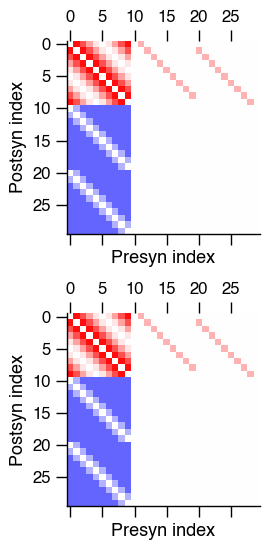

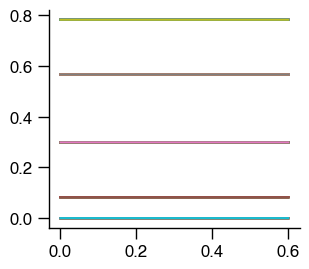

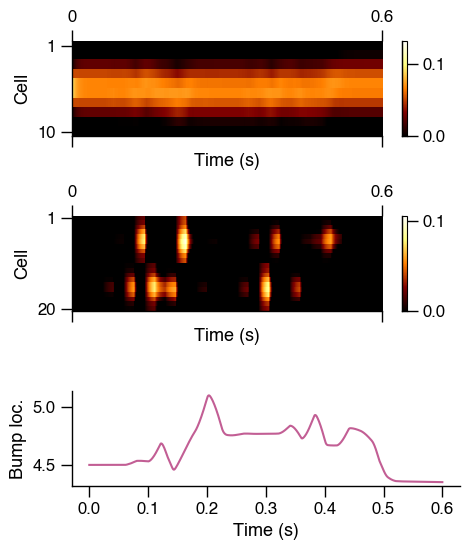

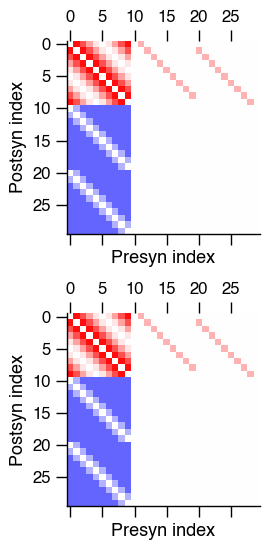

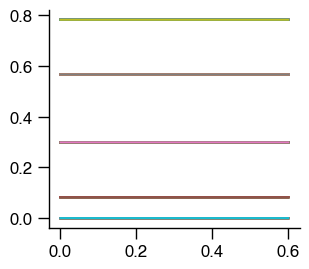

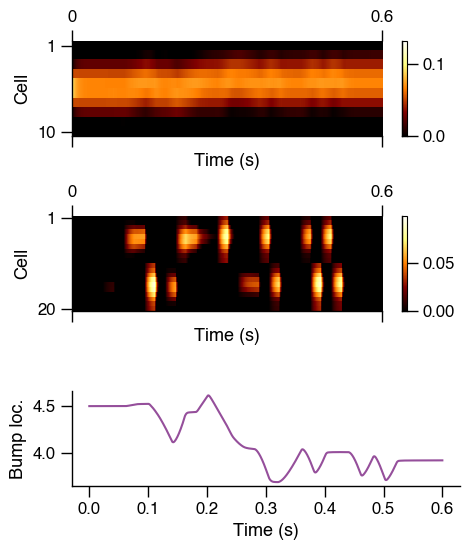

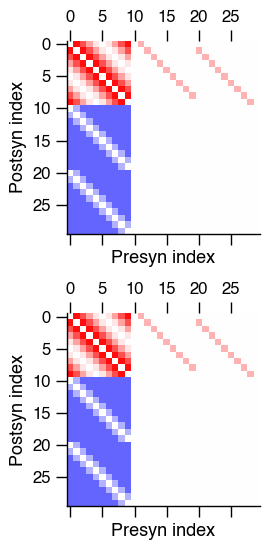

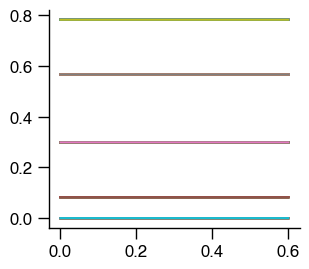

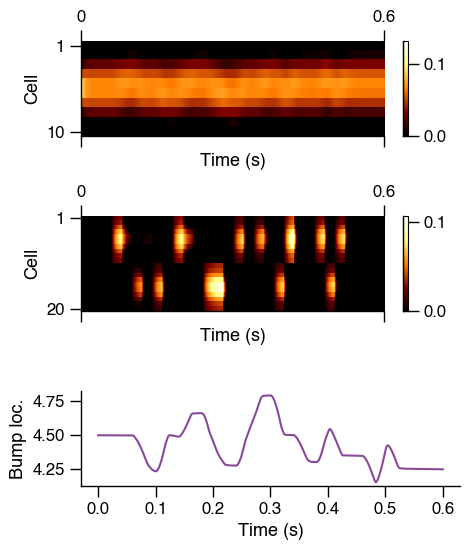

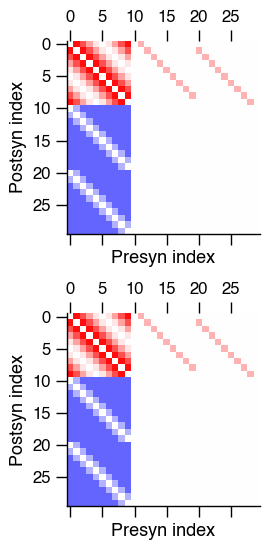

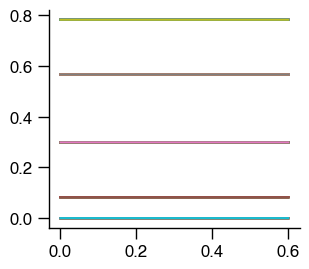

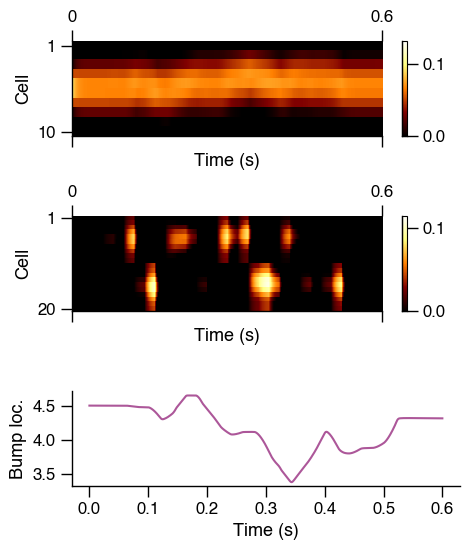

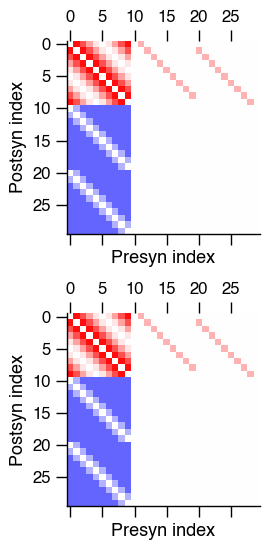

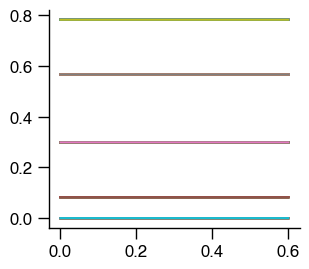

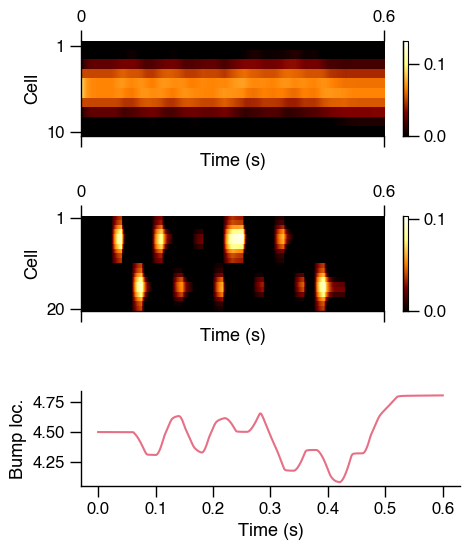

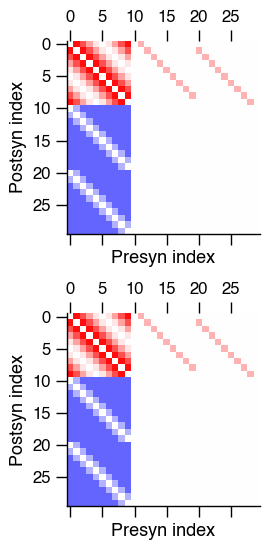

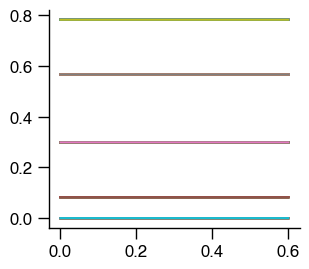

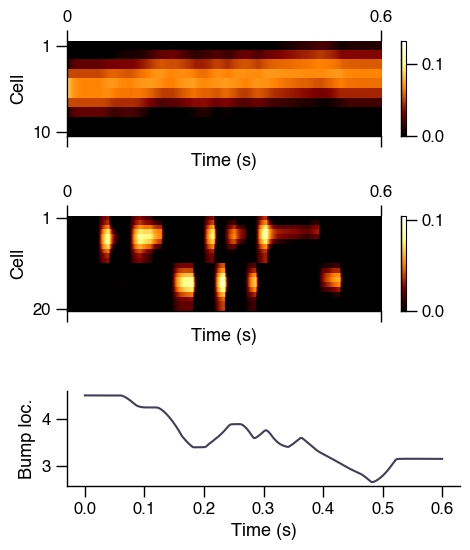

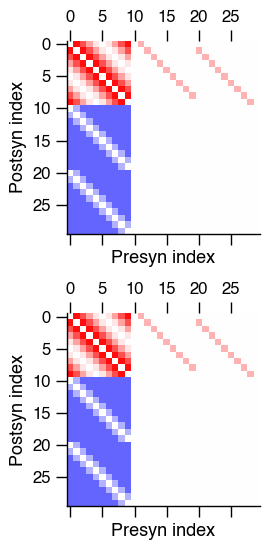

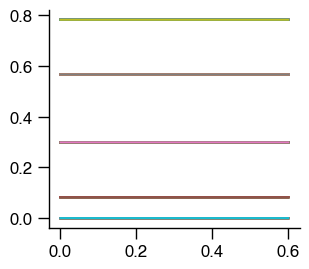

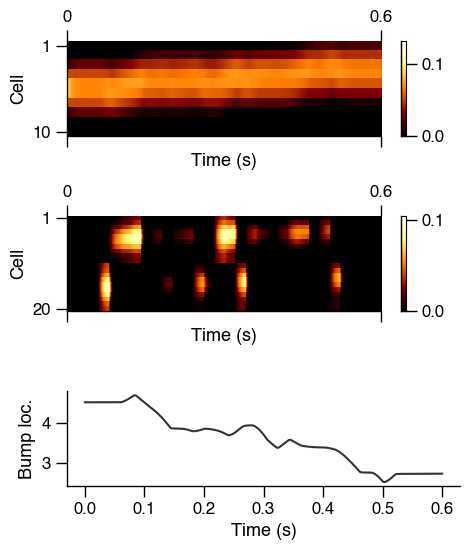

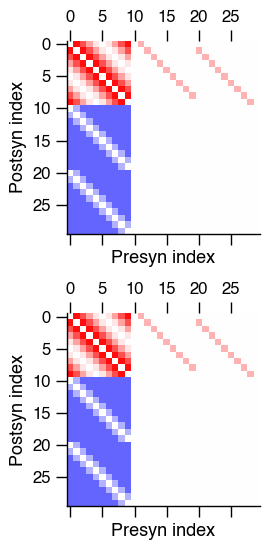

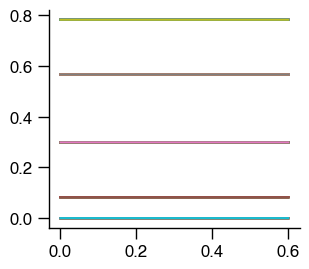

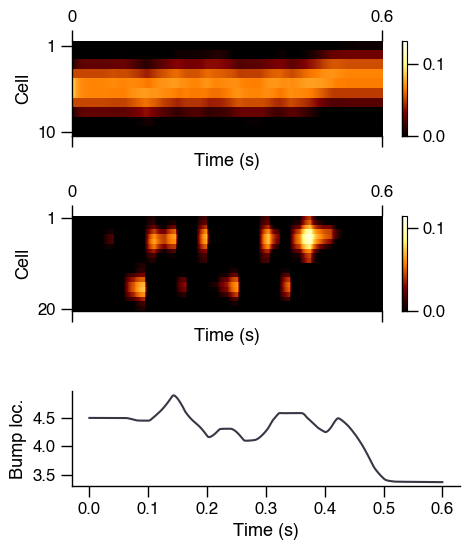

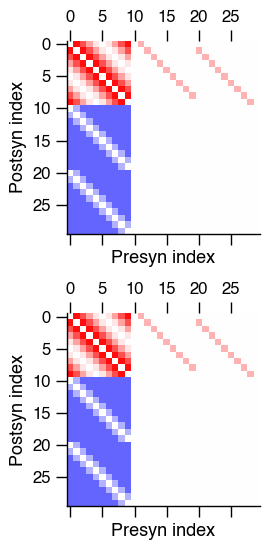

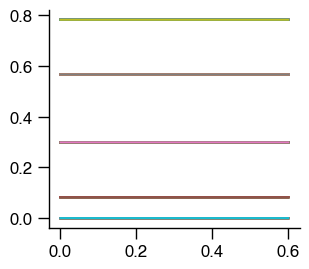

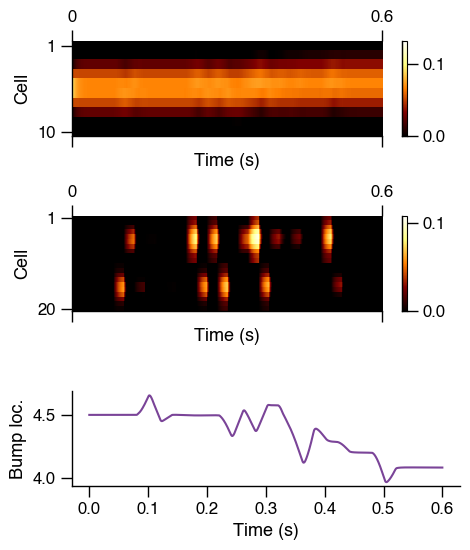

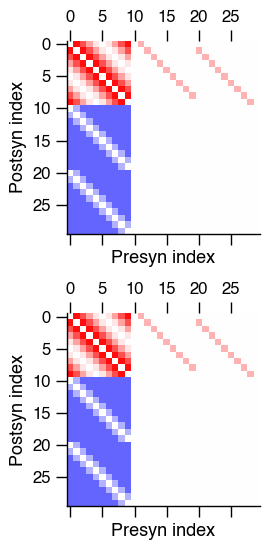

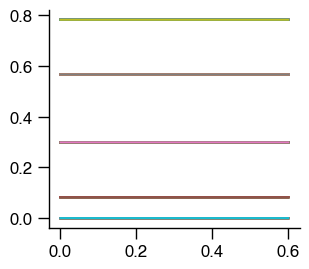

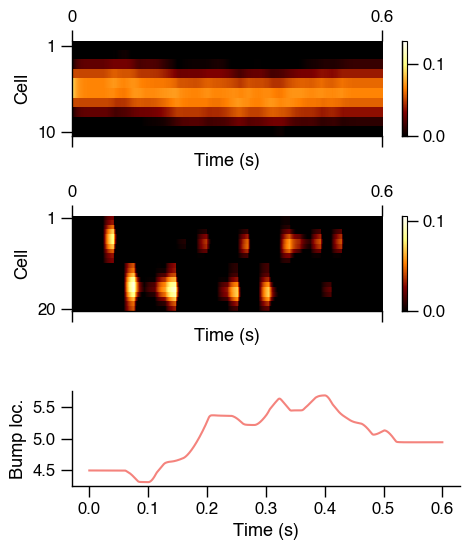

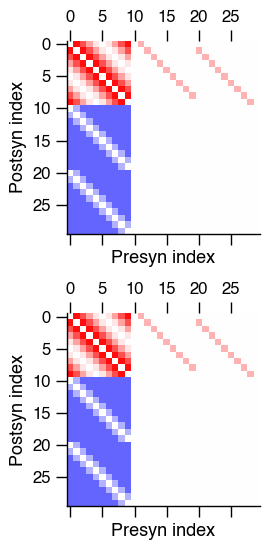

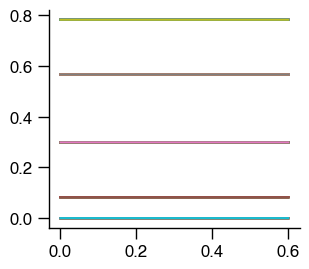

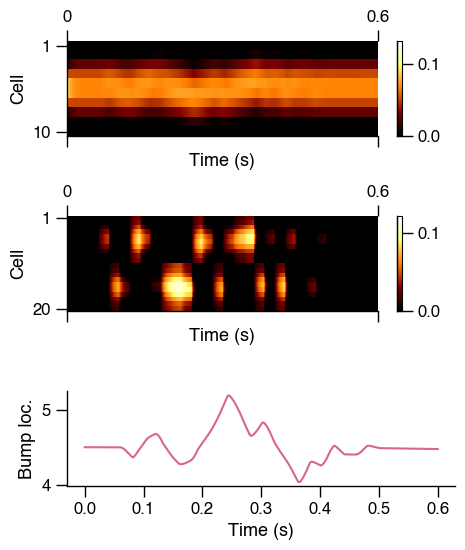

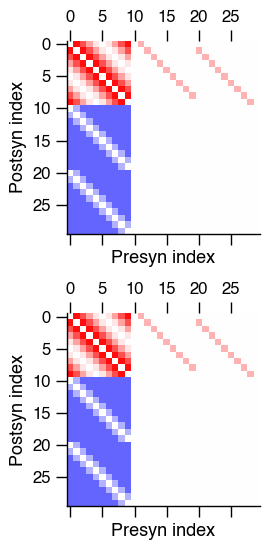

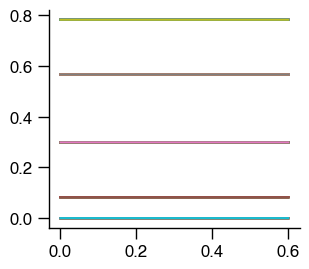

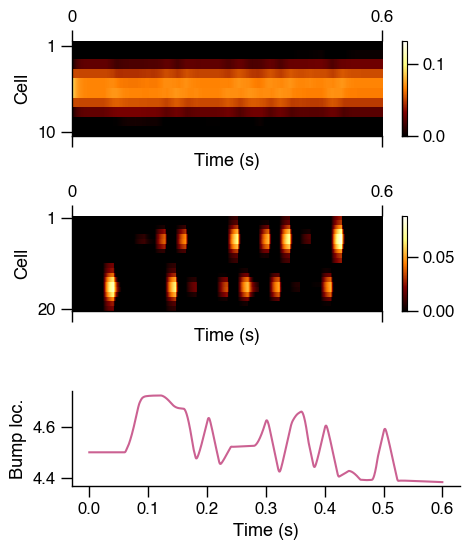

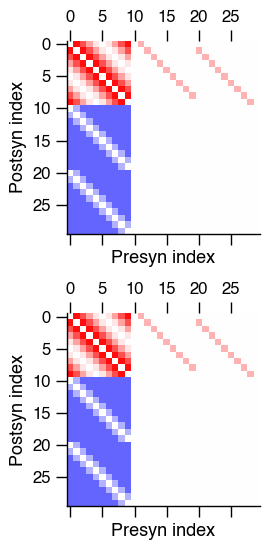

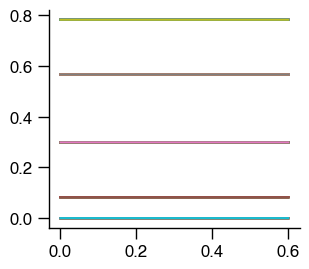

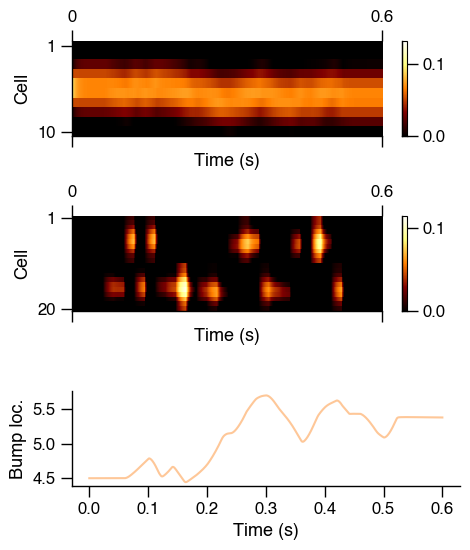

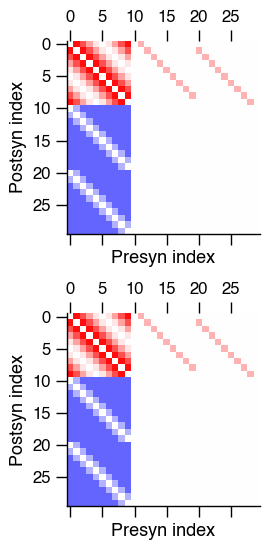

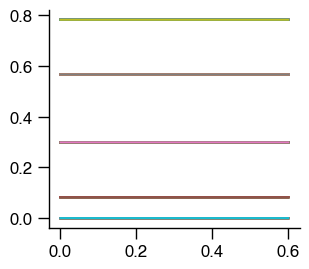

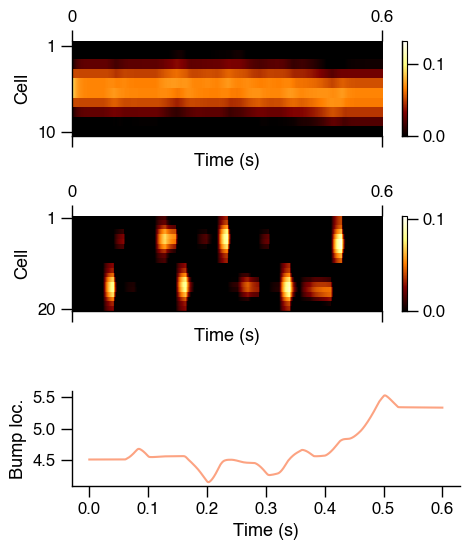

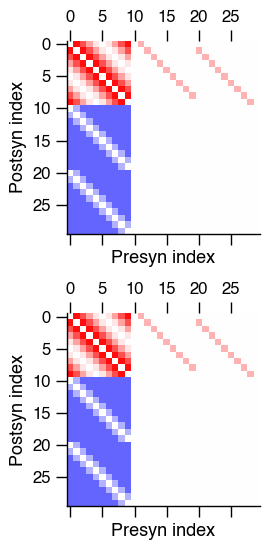

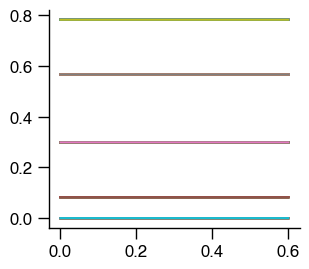

In [25]:
n = 10

def make_u_funcs(n_trials, n, t, dt):    
    def u_func(t_prime, inp):
        return np.concatenate(
            [
                np.array([
                    np.interp(t_prime, t, inp[2+i, :])
                    for i in range(n)
                ]),
                np.repeat(np.interp(t_prime, t, inp[0, :]), n),
                np.repeat(np.interp(t_prime, t, inp[1, :]), n),
            ]
        )

    funcs = []
    all_inps = []

    for i in range(n_trials):
        block_len = 0.05
        inp = np.zeros((3 + n, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if t_p >= 0.05 and t_p < 0.5:
                u_block = 0.15 * np.random.rand(2) + 0.05
                if np.random.rand() > 0.5:
                    u_block[0] = 0
                else:
                    u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:2, int(t_p/dt):int((t_p + block_len)/dt)] = u_block[:, None]
        inp[2:2+n, :] = 0.5
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(20, n, np.arange(0, 0.6, dt), dt=dt)

run_simulation(
    x_init_peak_locs=[0.5] * len(u_funcs),
    peak_amp=0.5,
    n=n,
    u_funcs=u_funcs,
    homeo_rate=0,
    learning_rate=0,
    alpha=0, 
    seed=20,
    weight_perturbation=0,
    noise_std=0.2,
    t_sim=(0, 0.6),
    make_cbar=True,
    w_e_scale=0.864, # strength of excitation between the cells forming the persistent activity representation
    w_pool_to_shift=0.5, # strength of inhibitory feedback from representation cells to input cells
    w_shift_to_pool=0.25, # strength of input cell projection to representation cells
    w_inh=np.random.normal(size=(n,), loc=1, scale=0) * 2,
    color_by=np.array([(inp[1].sum() - inp[0].sum()) for inp in all_inps]),
    plot_individual_traces=True,
)
None

Running simulations for 10 initial conditions...
Finished sim 1: 2.5774900913238525
Finished sim 2: 2.956681966781616
Finished sim 3: 2.49507212638855
Finished sim 4: 2.669664144515991
Finished sim 5: 2.5481550693511963
Finished sim 6: 2.797131061553955
Finished sim 7: 2.660269260406494


/var/folders/rp/n8h2l6w51774kxnq18z19s8r0000gn/T/ipykernel_1155/1626821448.py:319: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(3, 1, figsize=(12 * scale * width, 14 * scale))


Finished sim 8: 2.8196218013763428
Finished sim 9: 2.4236862659454346
Finished sim 10: 2.66028094291687


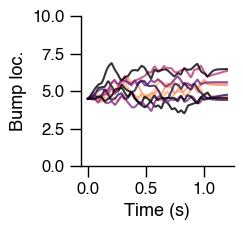

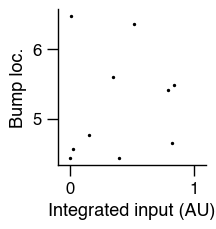

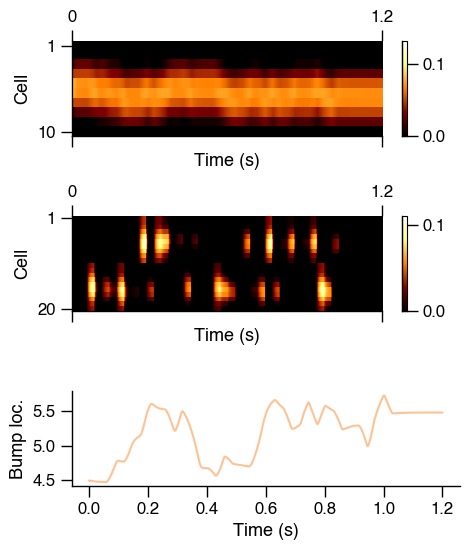

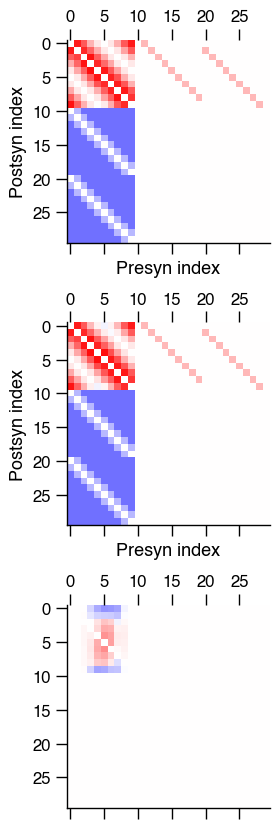

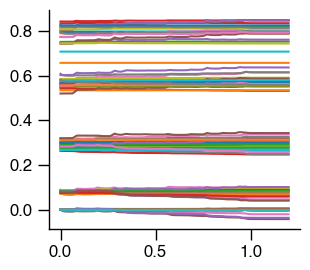

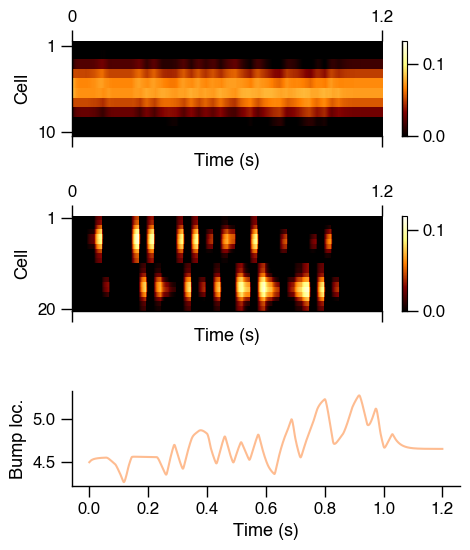

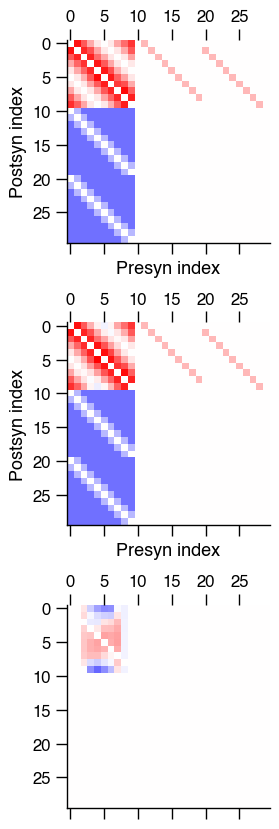

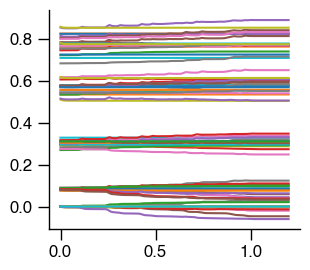

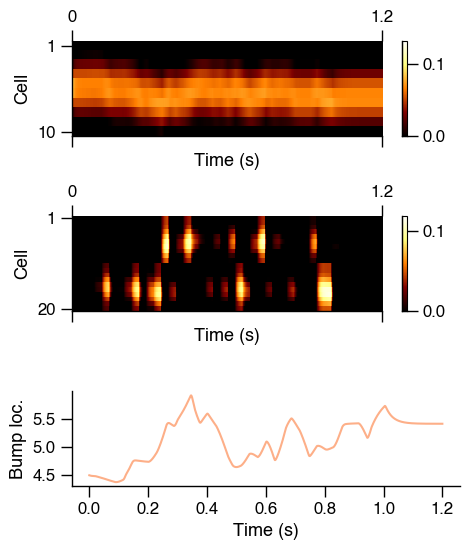

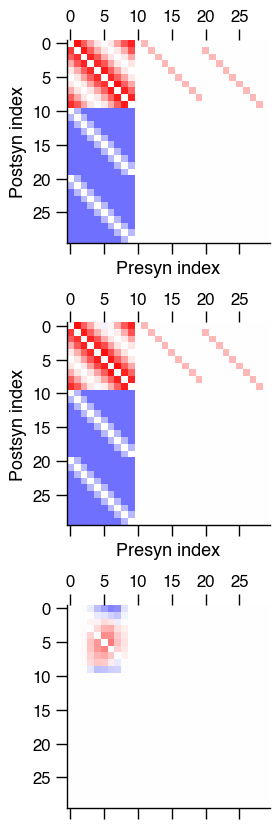

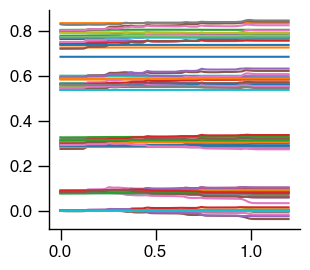

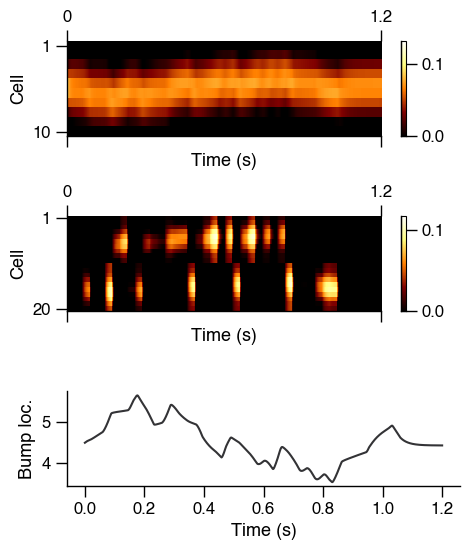

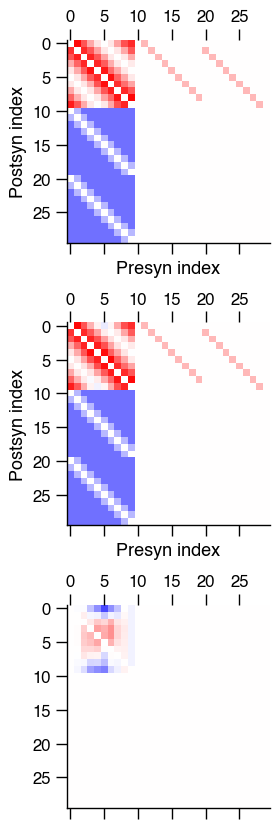

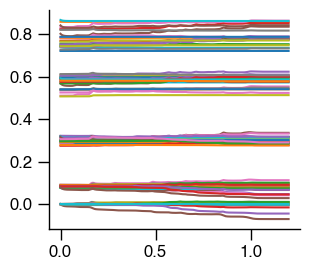

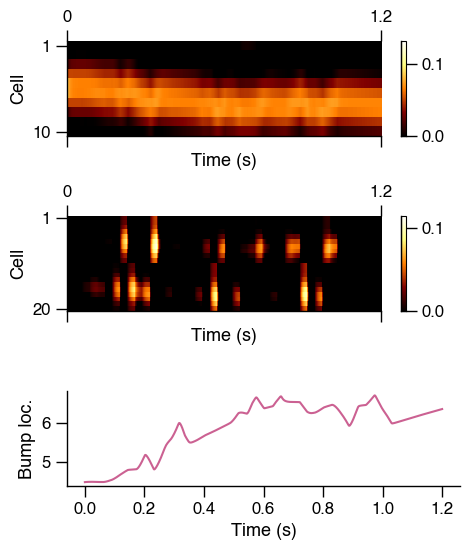

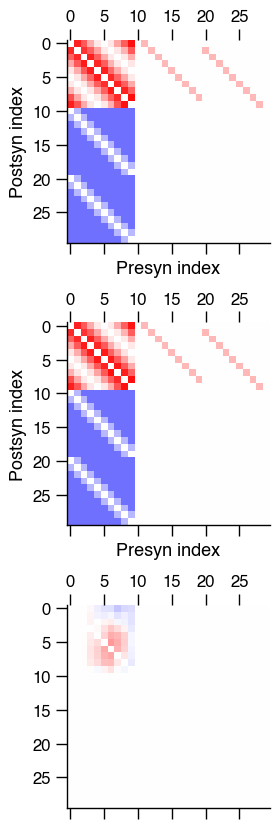

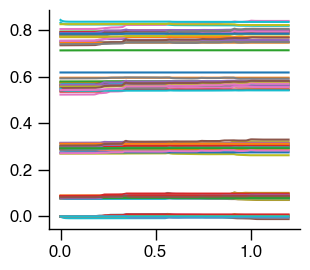

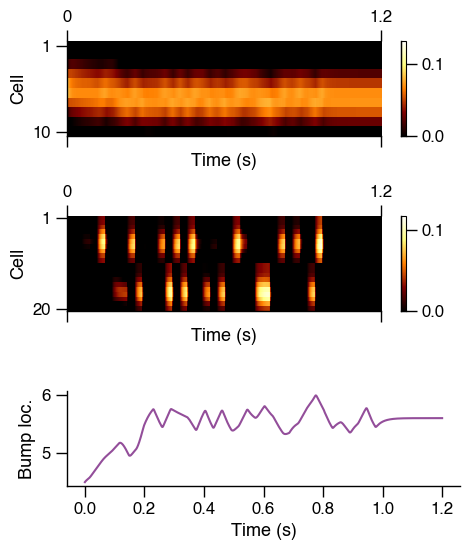

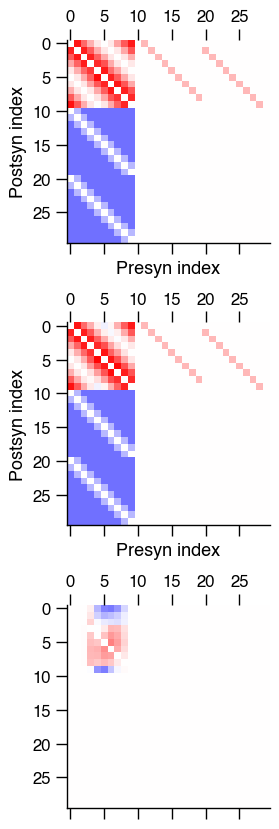

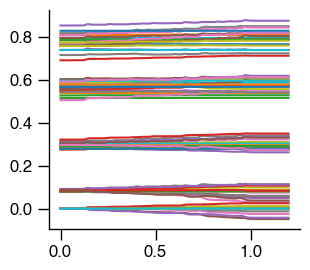

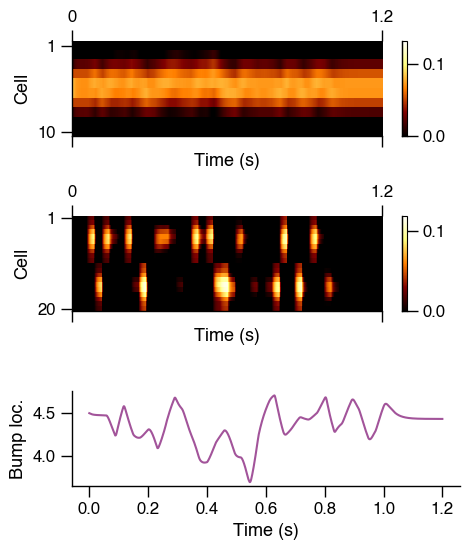

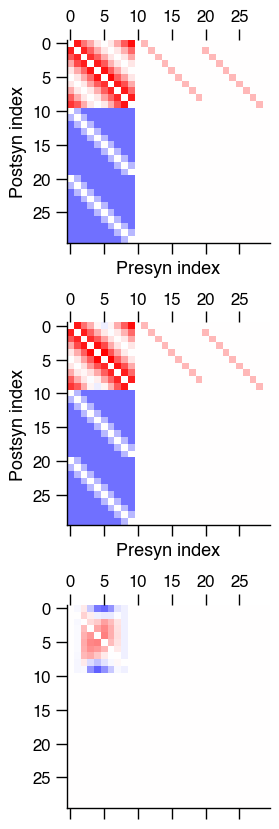

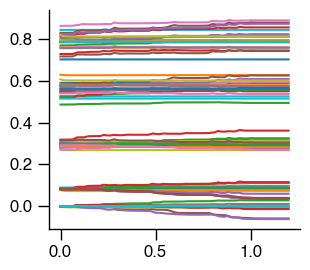

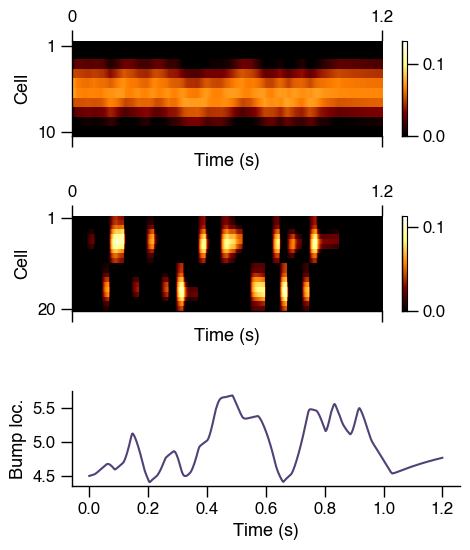

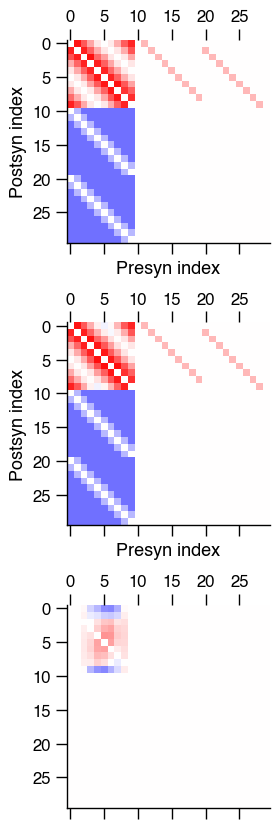

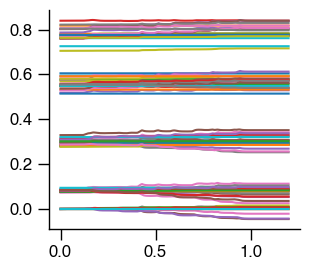

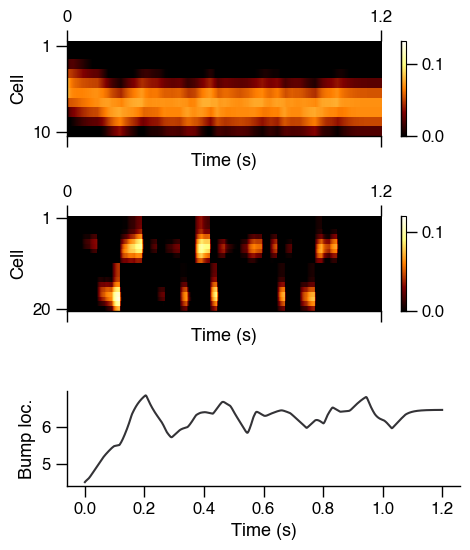

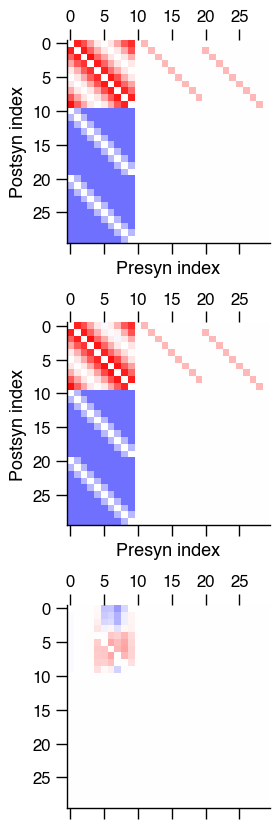

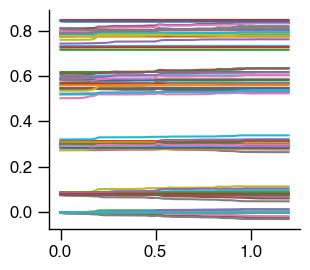

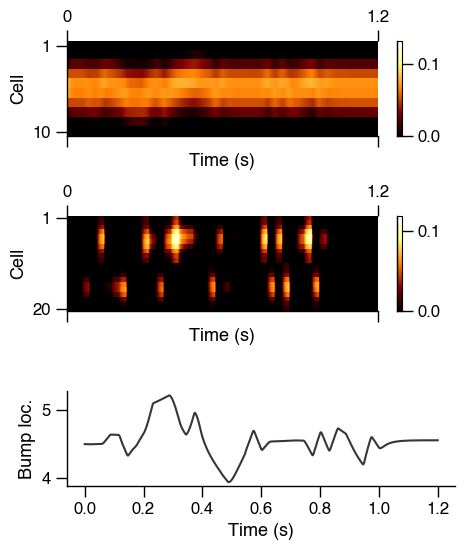

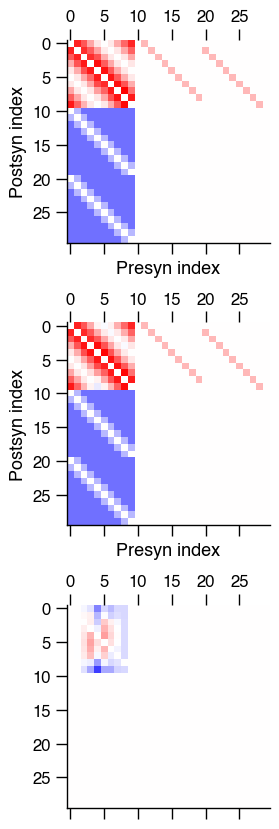

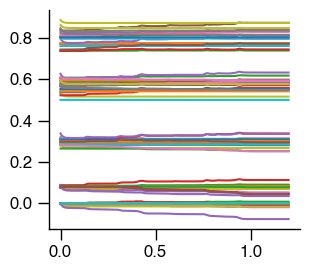

In [54]:
n = 10

def make_u_funcs(n_trials, n, t, dt):    
    def u_func(t_prime, inp):
        return np.concatenate(
            [
                np.array([
                    np.interp(t_prime, t, inp[2+i, :])
                    for i in range(n)
                ]),
                np.repeat(np.interp(t_prime, t, inp[0, :]), n),
                np.repeat(np.interp(t_prime, t, inp[1, :]), n),
            ]
        )

    funcs = []
    all_inps = []

    for i in range(n_trials):
        block_len = 0.05
        inp = np.zeros((3 + n, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if t_p >= 0.05 and t_p < 1:
                u_block = 0.15 * np.random.rand(2) + 0.05
                if np.random.rand() > 0.5:
                    u_block[0] = 0
                else:
                    u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:2, int(t_p/dt):int((t_p + block_len)/dt)] = u_block[:, None]
        inp[2:2+n, :] = 0.5
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(10, n, np.arange(0, 1.2, dt), dt=dt)

run_simulation(
    x_init_peak_locs=[0.5] * len(u_funcs),
    peak_amp=0.5,
    n=n,
    u_funcs=u_funcs,
    homeo_rate=10, 
    presyn_setpoint=3.5,
    learning_rate=1000,
    alpha=100 * 0.5,
    seed=20,
    weight_perturbation=0.05,
    noise_std=0.2,
    t_sim=(0, 1.2),
    make_cbar=True,
    w_e_scale=0.864, # strength of excitation between the cells forming the persistent activity representation
    w_pool_to_shift=0.5, # strength of inhibitory feedback from representation cells to input cells
    w_shift_to_pool=0.25, # strength of input cell projection to representation cells
    w_inh=np.random.normal(size=(n,), loc=1, scale=0) * 2,
    color_by=np.array([(inp[1].sum() - inp[0].sum()) for inp in all_inps]),
    plot_individual_traces=True,
)
None

Running simulations for 10 initial conditions...
Finished sim 1: 2.939832925796509
Finished sim 2: 2.6413679122924805
Finished sim 3: 2.457044839859009
Finished sim 4: 2.643918037414551
Finished sim 5: 3.135869264602661
Finished sim 6: 2.78912615776062
Finished sim 7: 2.7750189304351807


/var/folders/rp/n8h2l6w51774kxnq18z19s8r0000gn/T/ipykernel_1155/1626821448.py:319: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(3, 1, figsize=(12 * scale * width, 14 * scale))


Finished sim 8: 2.7168781757354736
Finished sim 9: 2.659122943878174
Finished sim 10: 2.7498512268066406


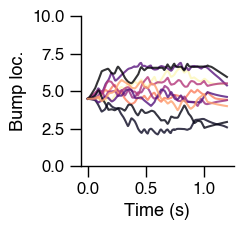

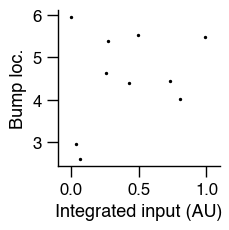

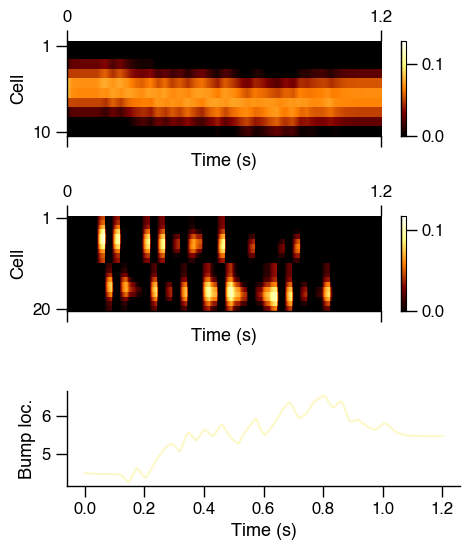

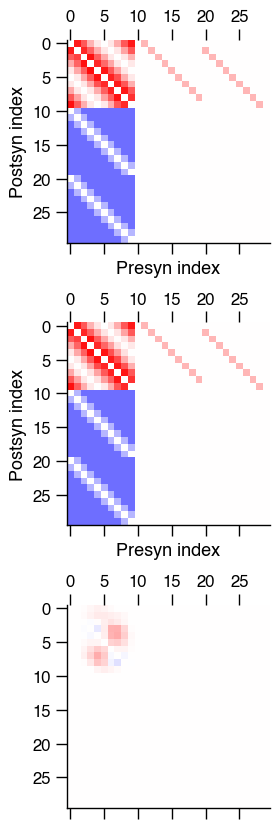

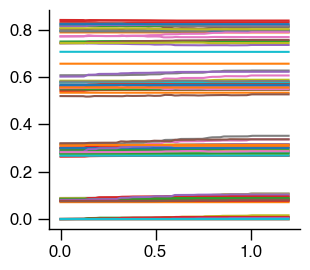

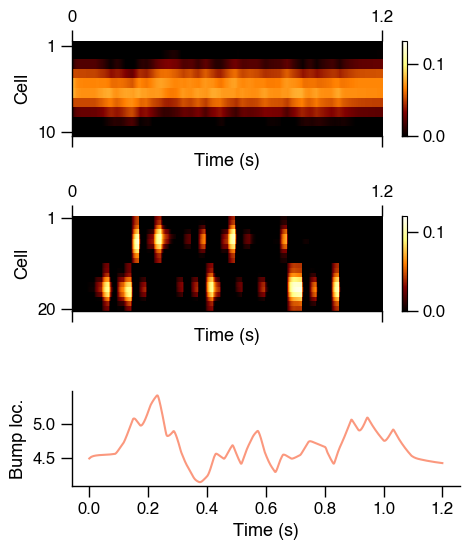

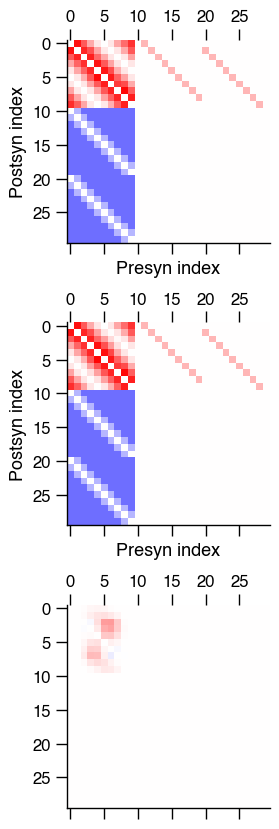

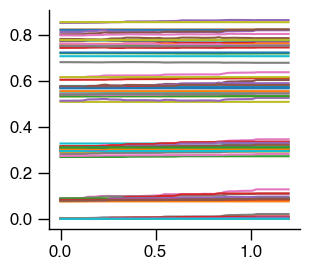

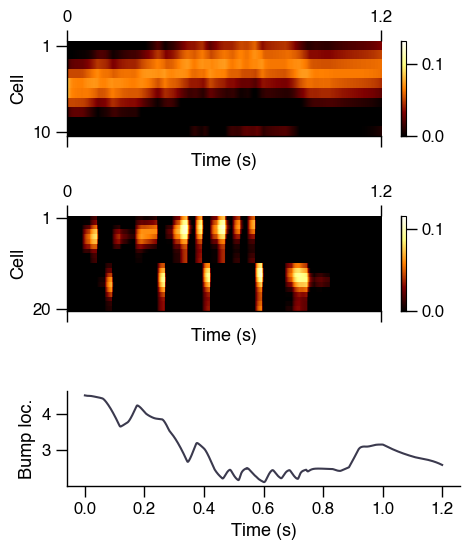

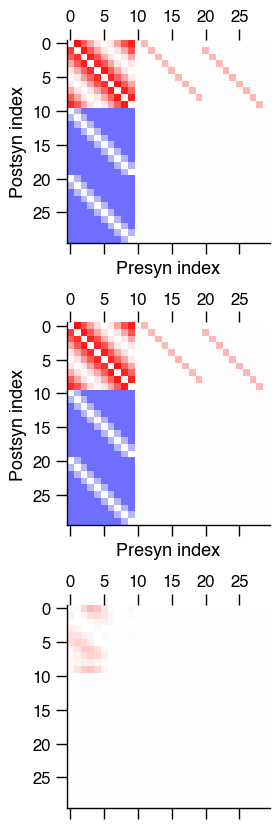

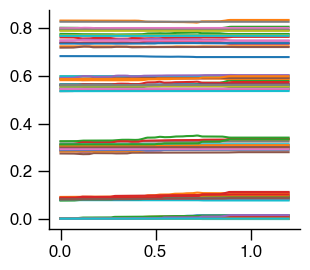

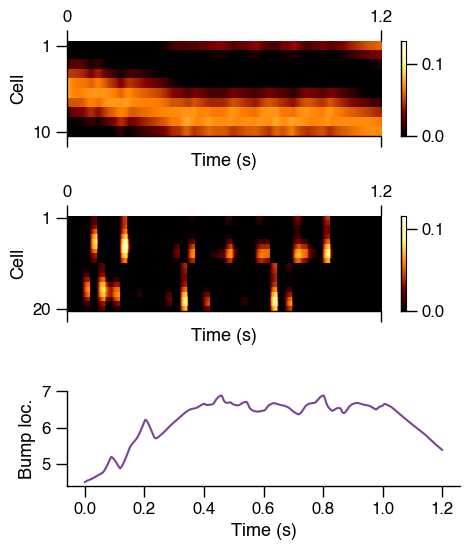

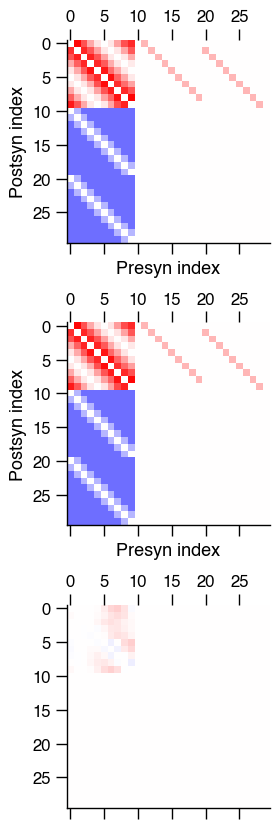

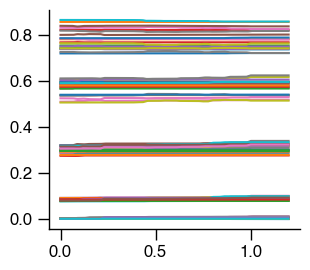

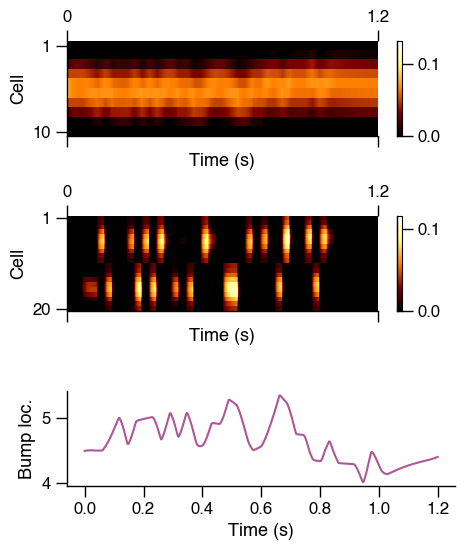

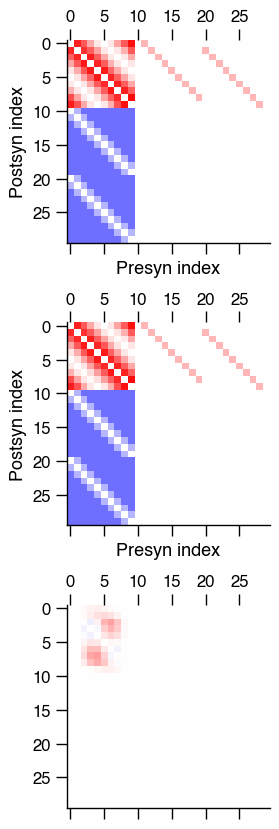

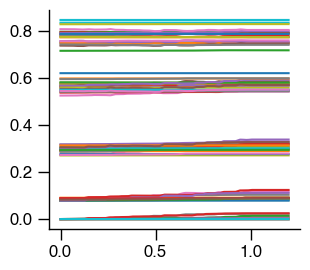

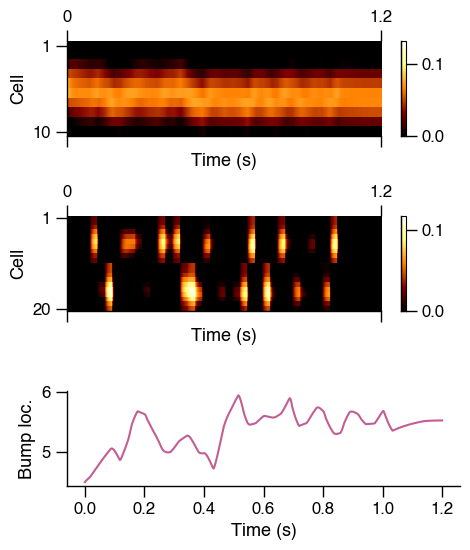

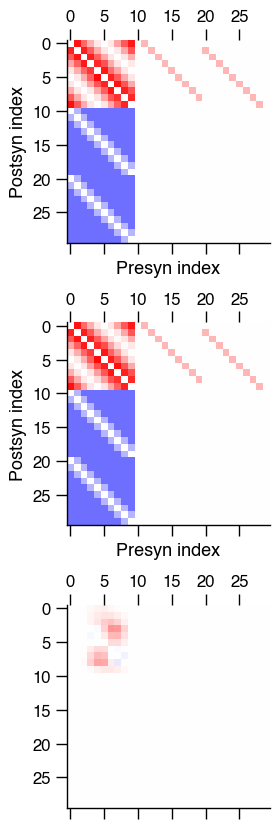

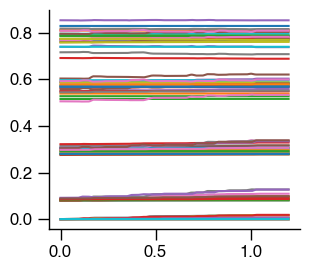

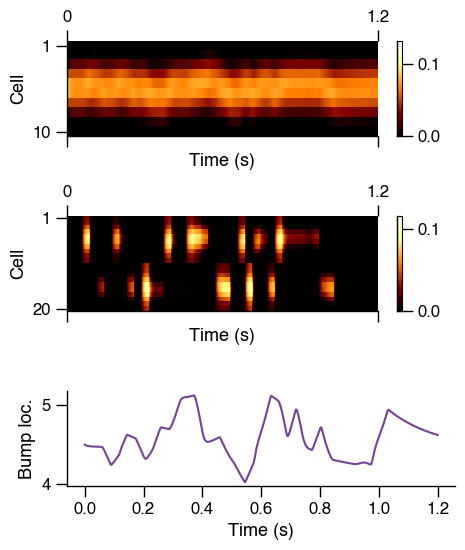

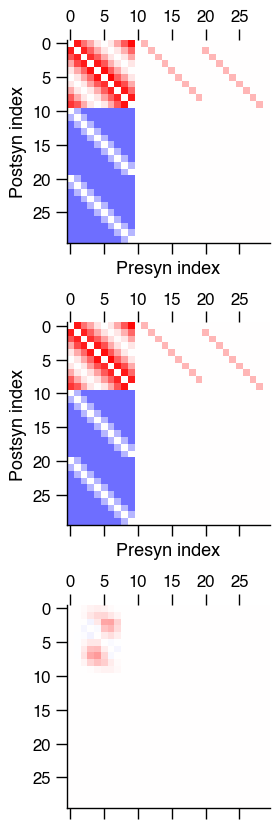

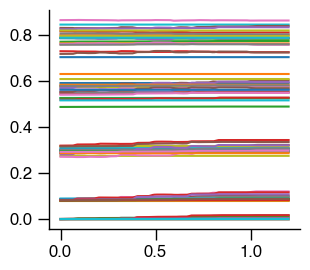

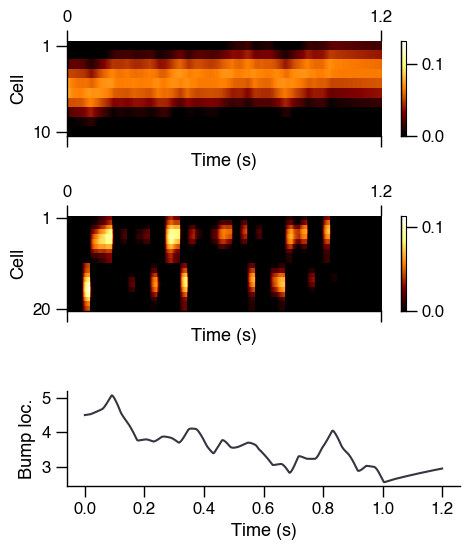

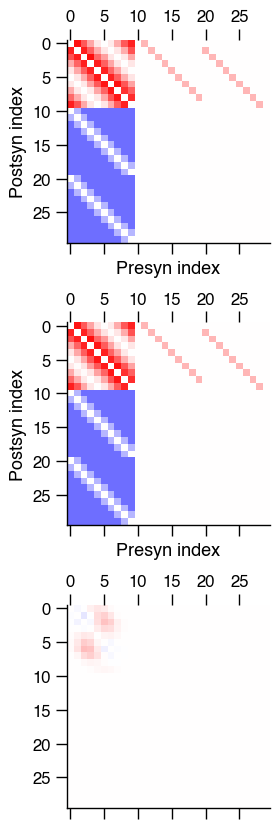

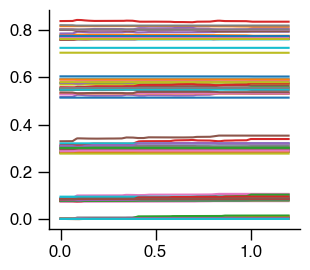

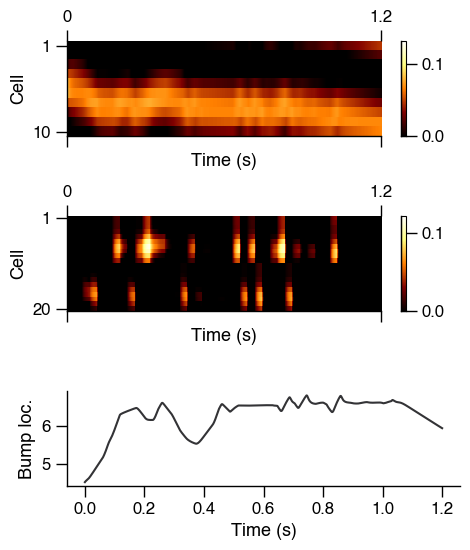

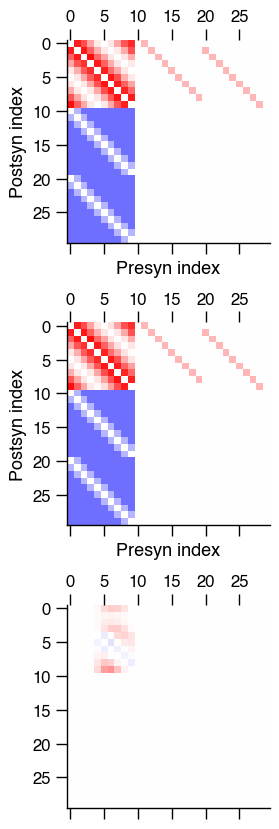

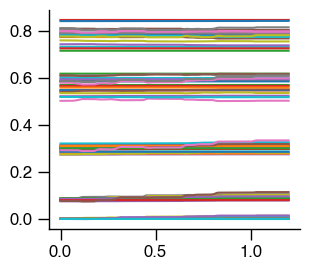

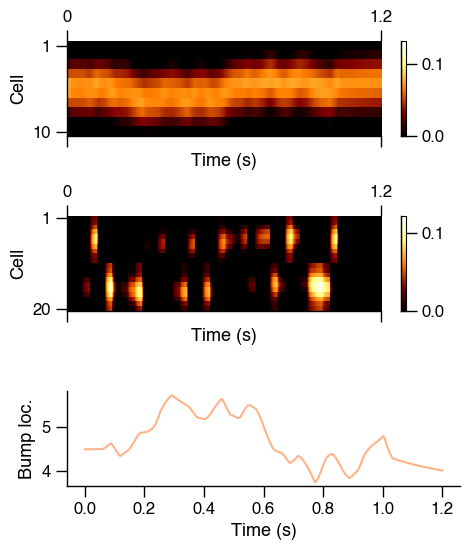

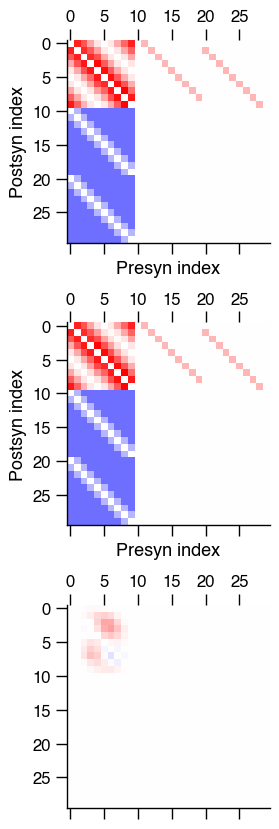

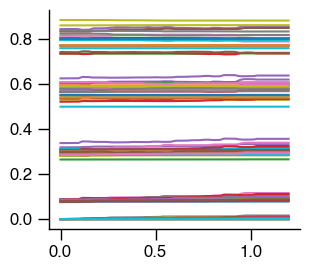

In [74]:
n = 10

def make_u_funcs(n_trials, n, t, dt):    
    def u_func(t_prime, inp):
        return np.concatenate(
            [
                np.array([
                    np.interp(t_prime, t, inp[2+i, :])
                    for i in range(n)
                ]),
                np.repeat(np.interp(t_prime, t, inp[0, :]), n),
                np.repeat(np.interp(t_prime, t, inp[1, :]), n),
            ]
        )

    funcs = []
    all_inps = []

    for i in range(n_trials):
        block_len = 0.05
        inp = np.zeros((3 + n, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if t_p >= 0.05 and t_p < 1:
                u_block = 0.15 * np.random.rand(2) + 0.05
                if np.random.rand() > 0.5:
                    u_block[0] = 0
                else:
                    u_block[1] = 0
            else:
                u_block = np.zeros((2))
            inp[:2, int(t_p/dt):int((t_p + block_len)/dt)] = u_block[:, None]
        inp[2:2+n, :] = 0.5
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(10, n, np.arange(0, 1.2, dt), dt=dt)

run_simulation(
    x_init_peak_locs=[0.5] * len(u_funcs),
    peak_amp=0.5,
    n=n,
    u_funcs=u_funcs,
    homeo_rate=0, #10, 
    presyn_setpoint=3.5,
    learning_rate=1000,
    alpha=100 * 0.1,
    seed=20,
    weight_perturbation=0.05,
    noise_std=0.2,
    t_sim=(0, 1.2),
    make_cbar=True,
    w_e_scale=0.864, # strength of excitation between the cells forming the persistent activity representation
    w_pool_to_shift=0.5, # strength of inhibitory feedback from representation cells to input cells
    w_shift_to_pool=0.25, # strength of input cell projection to representation cells
    w_inh=np.random.normal(size=(n,), loc=1, scale=0) * 2,
    color_by=np.array([(inp[1].sum() - inp[0].sum()) for inp in all_inps]),
    plot_individual_traces=True,
)
None